<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Construcción de Dataset de Imágenes</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Febrero de 2026</div>

  <div style="height:0.1rem;"></div>

</div>


Este *notebook* implementa el procesamiento y organización de imágenes multiespectrales de plantas de maíz y fríjol para construir un dataset de entrenamiento.

### Importar librerías

Librerías para procesamiento de imágenes, análisis numérico y manejo de archivos .mat

In [1]:
# Procesamiento numérico y visualización
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Manejo de archivos y expresiones regulares
import re
from collections import defaultdict
import os
import time
import shutil

# Procesamiento de imágenes y archivos MATLAB
from scipy.io import loadmat
import cv2
import pandas as pd

# 1. Exploración de los datos

## 1.1 Exploración de imágenes individuales

### Definir rutas de archivos base

Archivos de ejemplo para exploración: imagen multiespectral (REF) y su máscara de segmentación (CLASS)

In [2]:
# Rutas de ejemplo para fríjol
frijol_base_image_path = "data/mat/frijol/Nov_3_2021/REF__0000_T2R1.mat"
frijol_base_image_map_path = "data/mat/frijol/Nov_3_2021/CLASS__0000_T2R1.mat"

# Rutas de ejemplo para maíz
maiz_base_image_path = "data/mat/maiz/jun_23_2022/REF__0002_T1R1G10G4.mat"
maiz_base_image_map_path = "data/mat/maiz/jun_23_2022/CLASS__0002_T1R1G10G4.mat"

maiz_base_image_path_2 = "data/mat/maiz/Oct_27_2022/REF__0001_T1R1G1.mat"
maiz_base_image_map_path_2 = "data/mat/maiz/Oct_27_2022/CLASS__0001_T1R1G1.mat"

### Cargar y explorar estructura de archivos .mat

Los archivos .mat contienen:
- **'R'**: Array 3D con la imagen multiespectral (height × width × bands)
- **'class_map'**: Máscara 2D con la segmentación de hojas

In [3]:
# Cargar archivos .mat de fríjol
frijol_mat_data = loadmat(frijol_base_image_path)
frijol_mat_class_data = loadmat(frijol_base_image_map_path)

# Extraer imagen y máscara
frijol_imagen_base = frijol_mat_data['R']
frijol_imagen_base_mask = frijol_mat_class_data['class_map']

# Inspeccionar dimensiones y tipo de dato
print(f"Archivo: '{frijol_base_image_path}'")
print(f"Dimensiones del array: {frijol_imagen_base.shape}") # (height, width, bands)
print(f"Tipo de dato del array: {frijol_imagen_base.dtype}")

Archivo: 'data/mat/frijol/Nov_3_2021/REF__0000_T2R1.mat'
Dimensiones del array: (960, 1280, 10)
Tipo de dato del array: float64


In [4]:
# Cargar archivos .mat de maíz (primera muestra)
maiz_mat_data = loadmat(maiz_base_image_path)
maiz_mat_class_data = loadmat(maiz_base_image_map_path)

maiz_imagen_base = maiz_mat_data['R']
maiz_imagen_base_mask = maiz_mat_class_data['class_map']

print(f"Archivo: '{maiz_base_image_path}'")
print(f"Dimensiones del array: {maiz_imagen_base.shape}")
print(f"Tipo de dato del array: {maiz_imagen_base.dtype}")

Archivo: 'data/mat/maiz/jun_23_2022/REF__0002_T1R1G10G4.mat'
Dimensiones del array: (960, 1280, 10)
Tipo de dato del array: float64


In [5]:
# Cargar segunda muestra de maíz para comparación
maiz_mat_data_2 = loadmat(maiz_base_image_path_2)
maiz_mat_class_data_2 = loadmat(maiz_base_image_map_path_2)

maiz_imagen_base_2 = maiz_mat_data_2['R']
maiz_imagen_base_mask_2 = maiz_mat_class_data_2['class_map']

### Visualización de imagen y máscara

Mostrar una banda espectral (índice 8) y su máscara de segmentación correspondiente

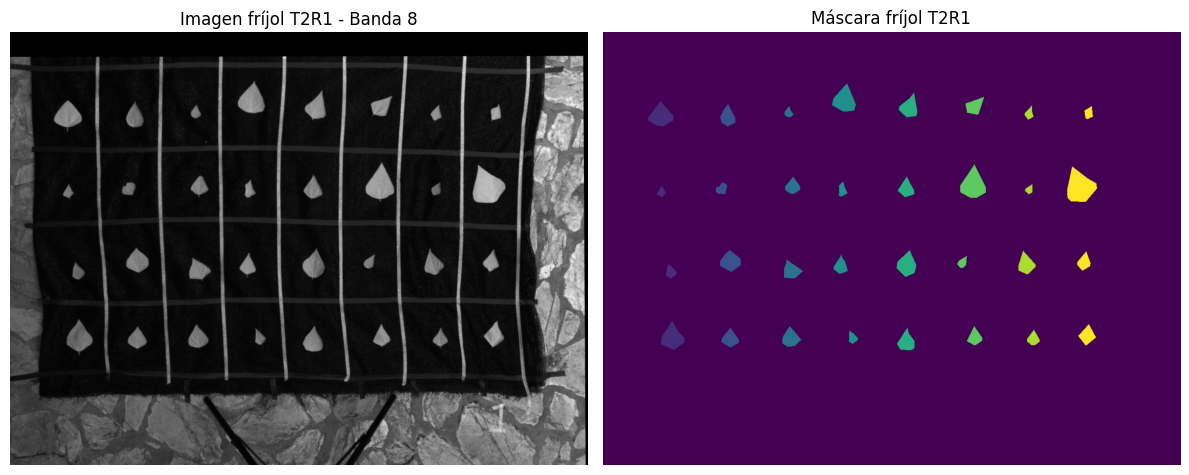

In [6]:
# Visualizar fríjol: imagen de banda 8 y su máscara
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(frijol_imagen_base[:,:,8], cmap='gray')
axes[0].set_title('Imagen fríjol T2R1 - Banda 8')
axes[0].axis('off')

axes[1].imshow(frijol_imagen_base_mask)
axes[1].set_title('Máscara fríjol T2R1')
axes[1].axis('off')

plt.tight_layout()
plt.show()

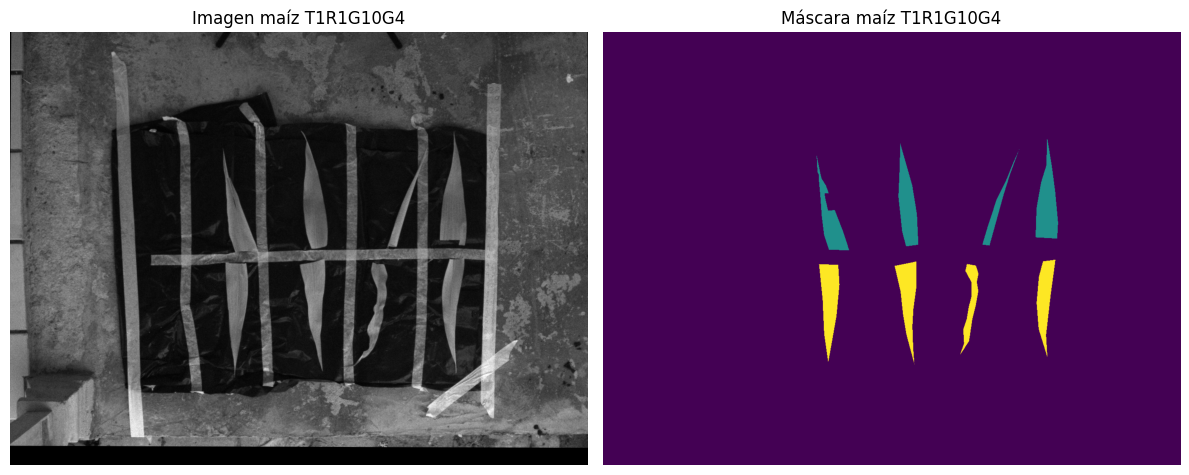

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(maiz_imagen_base[:,:,8], cmap='gray')
axes[0].set_title('Imagen maíz T1R1G10G4')
axes[0].axis('off')

axes[1].imshow(maiz_imagen_base_mask)
axes[1].set_title('Máscara maíz T1R1G10G4')
axes[1].axis('off')

plt.tight_layout()
plt.show()

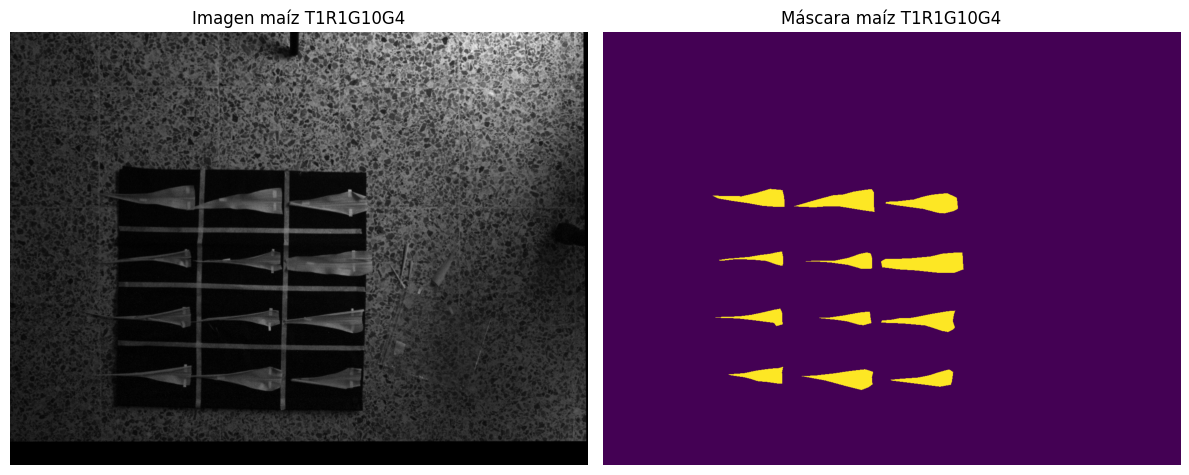

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(maiz_imagen_base_2[:,:,8], cmap='gray')
axes[0].set_title('Imagen maíz T1R1G10G4')
axes[0].axis('off')

axes[1].imshow(maiz_imagen_base_mask_2)
axes[1].set_title('Máscara maíz T1R1G10G4')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 2. Preprocesamiento de una imagen

## 2.1 Normalización

### Función de normalización Min-Max

Normaliza cada banda espectral independientemente al rango [0, 1]

In [9]:
def normalize_image(image):
    """
    Normalización Min-Max por banda individual.
    
    Args:
        image: Array 3D (height, width, bands)
    
    Returns:
        imagen_norm: Array normalizado con valores en [0, 1]
    """
    imagen_norm = np.empty_like(image, dtype=np.float32)

    for i in range(image.shape[2]):
        band = image[:,:,i]
        band_min = band.min()
        band_max = band.max()
        # Normalizar cada banda al rango [0, 1]
        imagen_norm[:,:,i] = (band - band_min) / (band_max - band_min + 1e-6)  # Evita división por cero

    return imagen_norm

In [10]:
# Normalizar imágenes de fríjol y maíz
frijol_imagen_norm = normalize_image(frijol_imagen_base)
maiz_imagen_norm = normalize_image(maiz_imagen_base)

In [11]:
# Seleccionar banda 6 para procesamiento de ejemplo
frijol_original_image_array = frijol_imagen_norm[:,:,6]
maiz_original_image_array = maiz_imagen_norm[:,:,6]

## 2.2 Segmentar hojas

Aplicar máscara binaria para aislar las hojas del fondo

In [12]:
# Binarizar máscaras (0 o 255)
_, frijol_image_mask_binary = cv2.threshold(frijol_imagen_base_mask, 0, 255, cv2.THRESH_BINARY)
_, maiz_image_mask_binary = cv2.threshold(maiz_imagen_base_mask, 0, 255, cv2.THRESH_BINARY)

# Aplicar máscaras a las imágenes originales usando operación AND
frijol_result = cv2.bitwise_and(frijol_original_image_array, frijol_original_image_array, mask=frijol_image_mask_binary)
maiz_result = cv2.bitwise_and(maiz_original_image_array, maiz_original_image_array, mask=maiz_image_mask_binary)

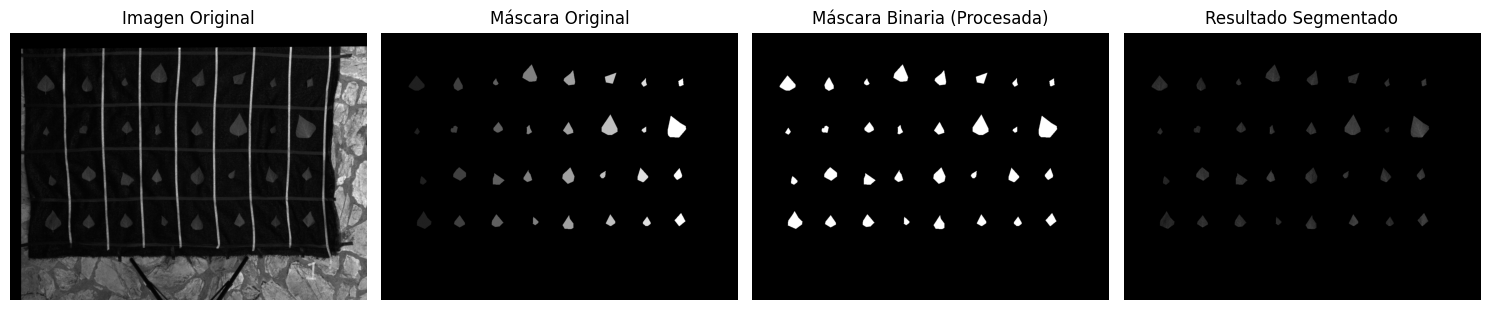

In [13]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(frijol_original_image_array, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Máscara Original')
plt.imshow(frijol_imagen_base_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Máscara Binaria (Procesada)')
plt.imshow(frijol_image_mask_binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Resultado Segmentado')
plt.imshow(cv2.cvtColor(frijol_result, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

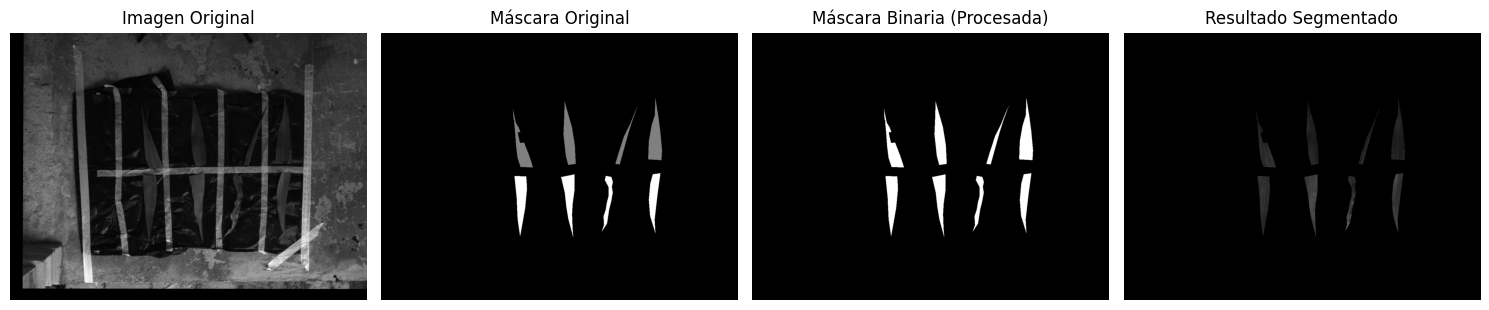

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(maiz_original_image_array, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Máscara Original')
plt.imshow(maiz_imagen_base_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Máscara Binaria (Procesada)')
plt.imshow(maiz_image_mask_binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Resultado Segmentado')
plt.imshow(cv2.cvtColor(maiz_result, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Etiquetado

## 3.1 Recorte de las hojas

### 3.1.1 Método 1: Recorte con `connectedComponentsWithStats`

Usa etiquetado de componentes conectados para identificar objetos individuales

In [10]:
imagen_base = frijol_imagen_base
imagen_base_mask = frijol_imagen_base_mask

imagen = imagen_base[:,:,0]
mask = imagen_base_mask

In [11]:
def visualizar_objetos_centrados(data, num_labels, cols=8):
    """Función auxiliar para visualizar los objetos centrados en el origen, organizados en varias filas y hasta 8 columnas."""
    num_objetos = num_labels - 1
    filas = int(np.ceil(num_objetos / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(5 * cols, 5 * filas))
    axes = np.array(axes).reshape(-1) 

    for i in range(num_objetos):
        label_id = i + 1
        coords = data[label_id]
        ax = axes[i]
        ax.scatter(coords[:, 0], coords[:, 1], s=1, c='blue')
        ax.plot(0, 0, 'r+', markersize=10)
        ax.set_title(f"Objeto {label_id} Centrado")
        ax.set_xlabel("Posición Relativa X")
        ax.set_ylabel("Posición Relativa Y")
        ax.grid(True)
        ax.set_aspect('equal', adjustable='box')
        ax.invert_yaxis()

    for j in range(num_objetos, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


In [7]:
def calcular_posiciones_relativas(mask: np.ndarray, save_dir: str = None, original_img: np.ndarray = None, out_size: tuple = (128, 128)):
    """
    Encuentra todos los objetos en una máscara binaria, calcula posiciones relativas
    y guarda los objetos como imágenes separadas si se especifica save_dir.

    Args:
        mask (np.ndarray): Máscara binaria o en escala de grises.
        save_dir (str, optional): Carpeta donde guardar los recortes de objetos.
        original_img (np.ndarray, optional): Imagen original en gris o RGB.
        out_size (tuple, optional): Tamaño estándar para redimensionar (w, h).

    Returns:
        tuple: (posiciones_relativas_por_objeto, labels_matrix, centroids, num_labels, recortes)
    """
    _, mask_bin = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

    num_labels, labels_matrix, stats, centroids = cv2.connectedComponentsWithStats(
        mask_bin, connectivity=8, ltype=cv2.CV_32S)

    posiciones_relativas_por_objeto = {}
    recortes = {}

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for i in range(1, num_labels):  
        cx, cy = centroids[i]
        pixeles_y, pixeles_x = np.where(labels_matrix == i)

        rel_x = pixeles_x - cx
        rel_y = pixeles_y - cy
        posiciones_relativas = np.vstack((rel_x, rel_y)).T
        posiciones_relativas_por_objeto[i] = posiciones_relativas

        # Recorte del objeto
        x, y, w, h, area = stats[i]
        objeto_mask = mask_bin[y:y+h, x:x+w]

        if original_img is not None:
            objeto_img = original_img[y:y+h, x:x+w]
            objeto_img = cv2.bitwise_and(objeto_img, objeto_img, mask=objeto_mask)
        else:
            objeto_img = objeto_mask

        # Normalizar valores al rango 0–255
        if objeto_img.max() > 0:
            objeto_img = (objeto_img / objeto_img.max()) * 255
        objeto_img = objeto_img.astype(np.uint8)

        # Redimensionar a tamaño estándar
        objeto_img_resized = cv2.resize(objeto_img, out_size, interpolation=cv2.INTER_AREA)
        recortes[i] = objeto_img_resized

        # Guardar
        if save_dir is not None:
            filename = os.path.join(save_dir, f"objeto_{i}.png")
            cv2.imwrite(filename, objeto_img_resized)

    return posiciones_relativas_por_objeto, labels_matrix, centroids, num_labels, recortes

In [13]:
def visualizar_recortes(recortes, cols=8):
    """Nueva visualización: muestra los recortes de la imagen original"""
    num_objetos = len(recortes)
    filas = int(np.ceil(num_objetos / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(5 * cols, 5 * filas))
    axes = np.array(axes).reshape(-1)

    for i, (label_id, img) in enumerate(recortes.items()):
        ax = axes[i]
        if len(img.shape) == 2:  # gris
            ax.imshow(img, cmap="gray")
        else:  # RGB
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Objeto {label_id}")
        ax.axis("off")

    for j in range(num_objetos, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

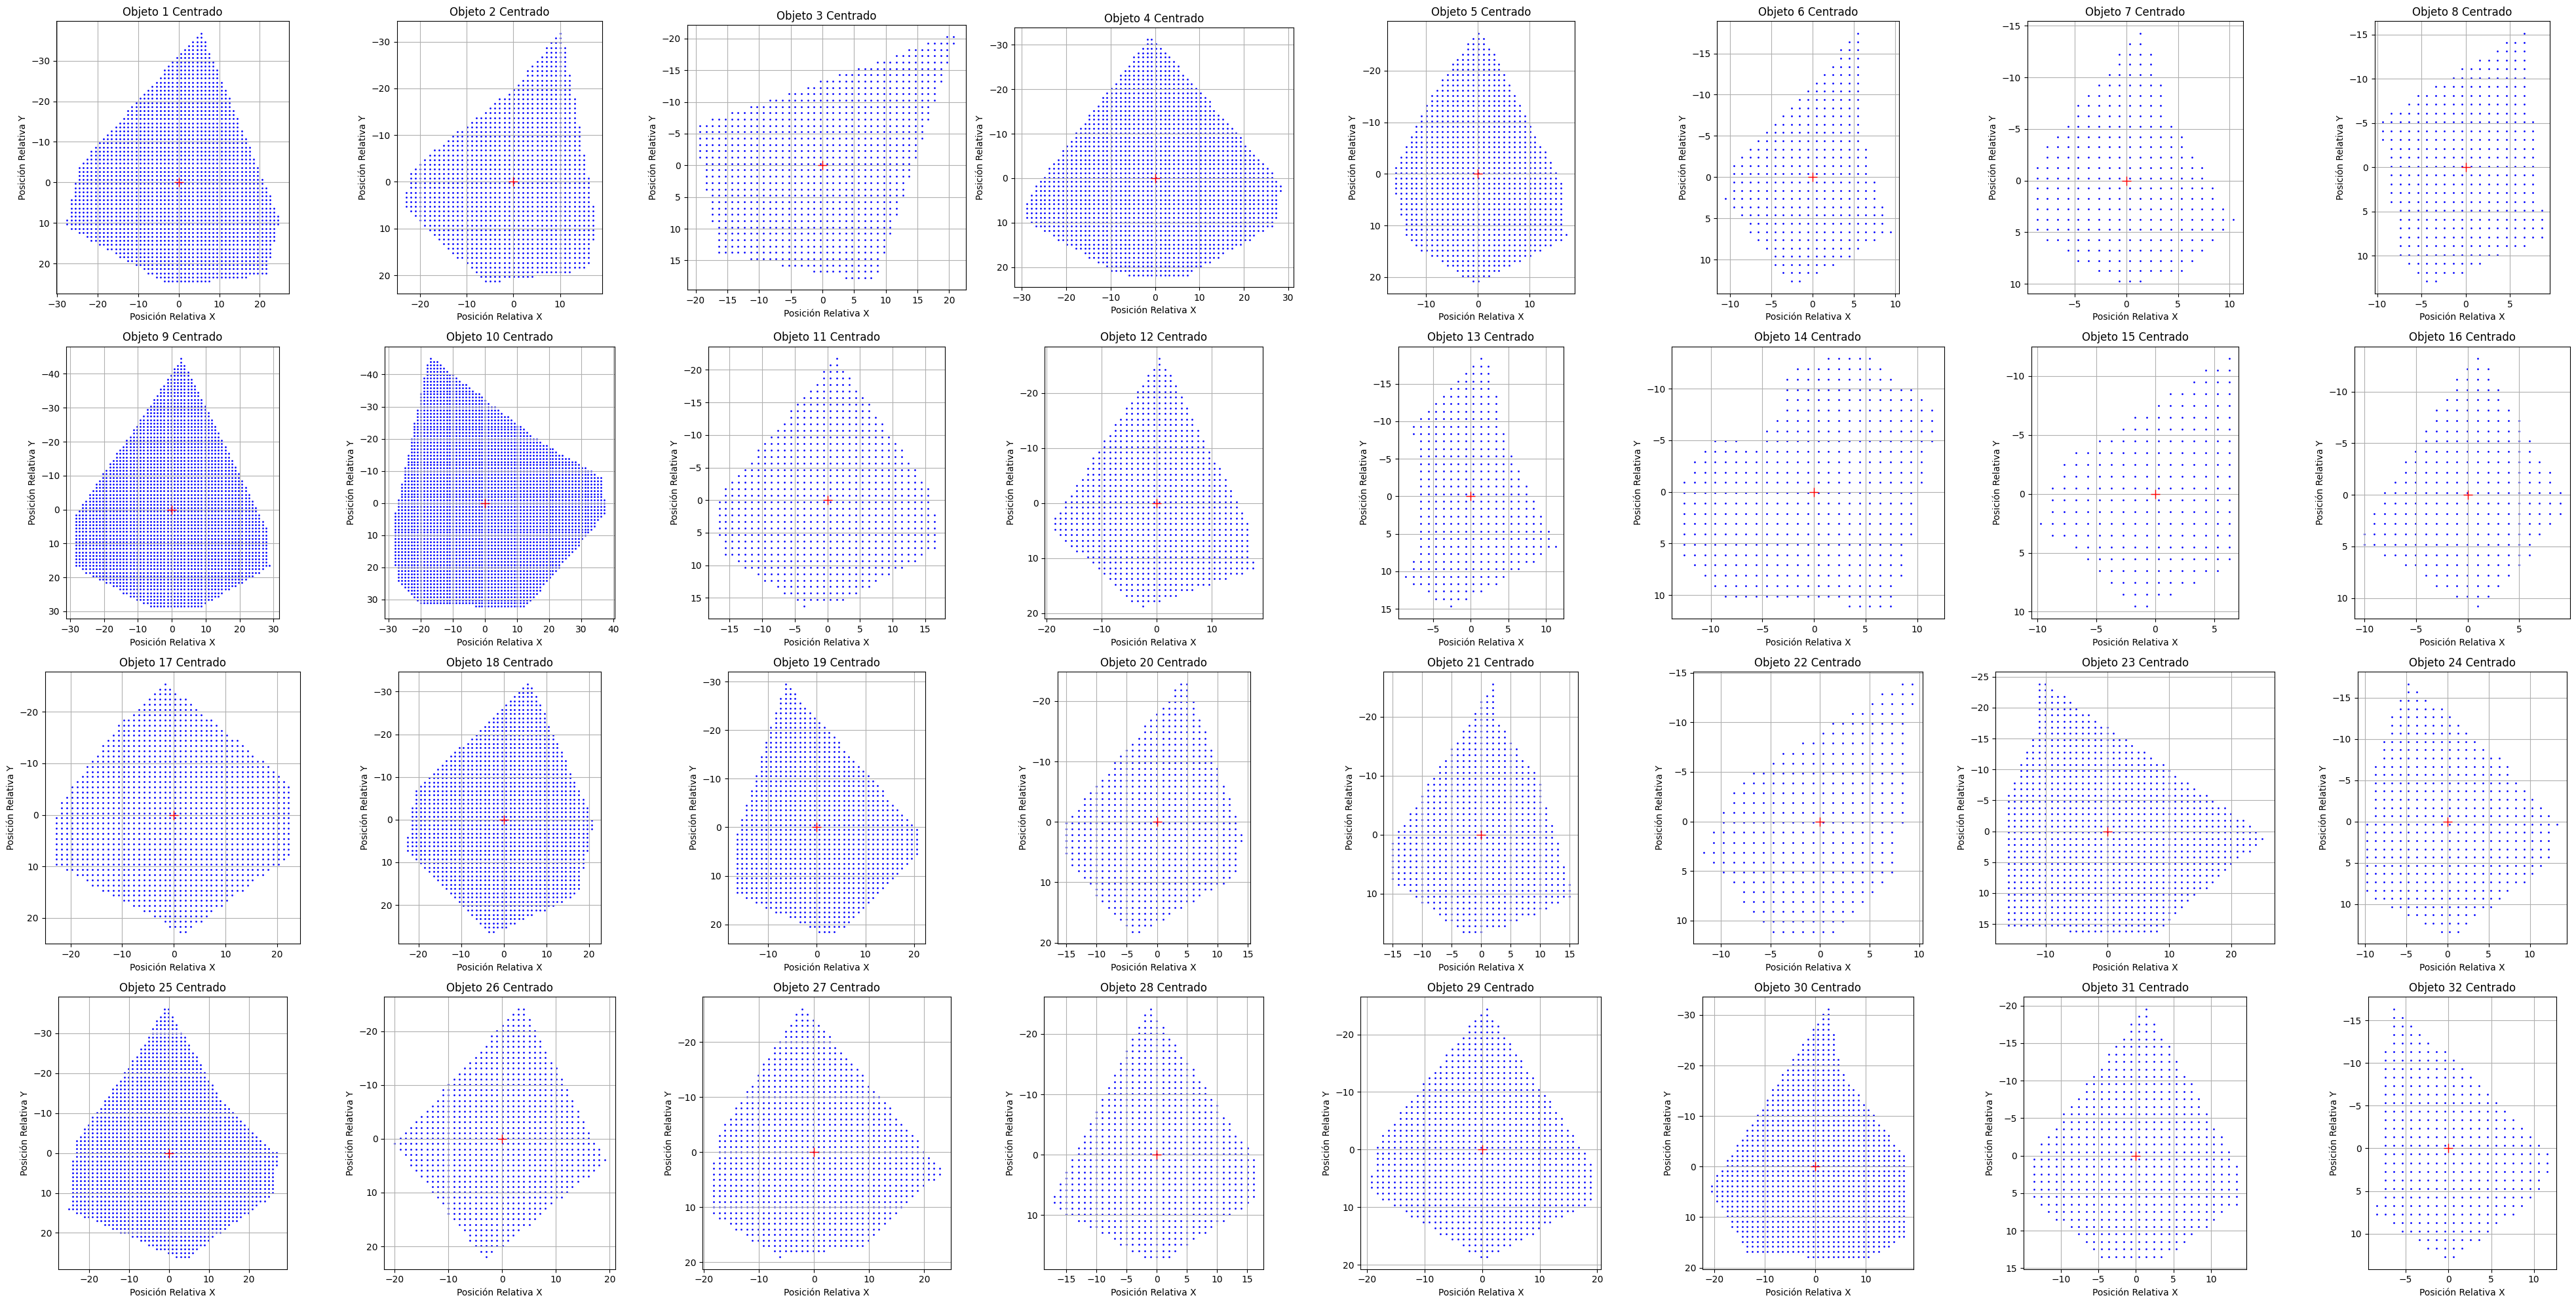

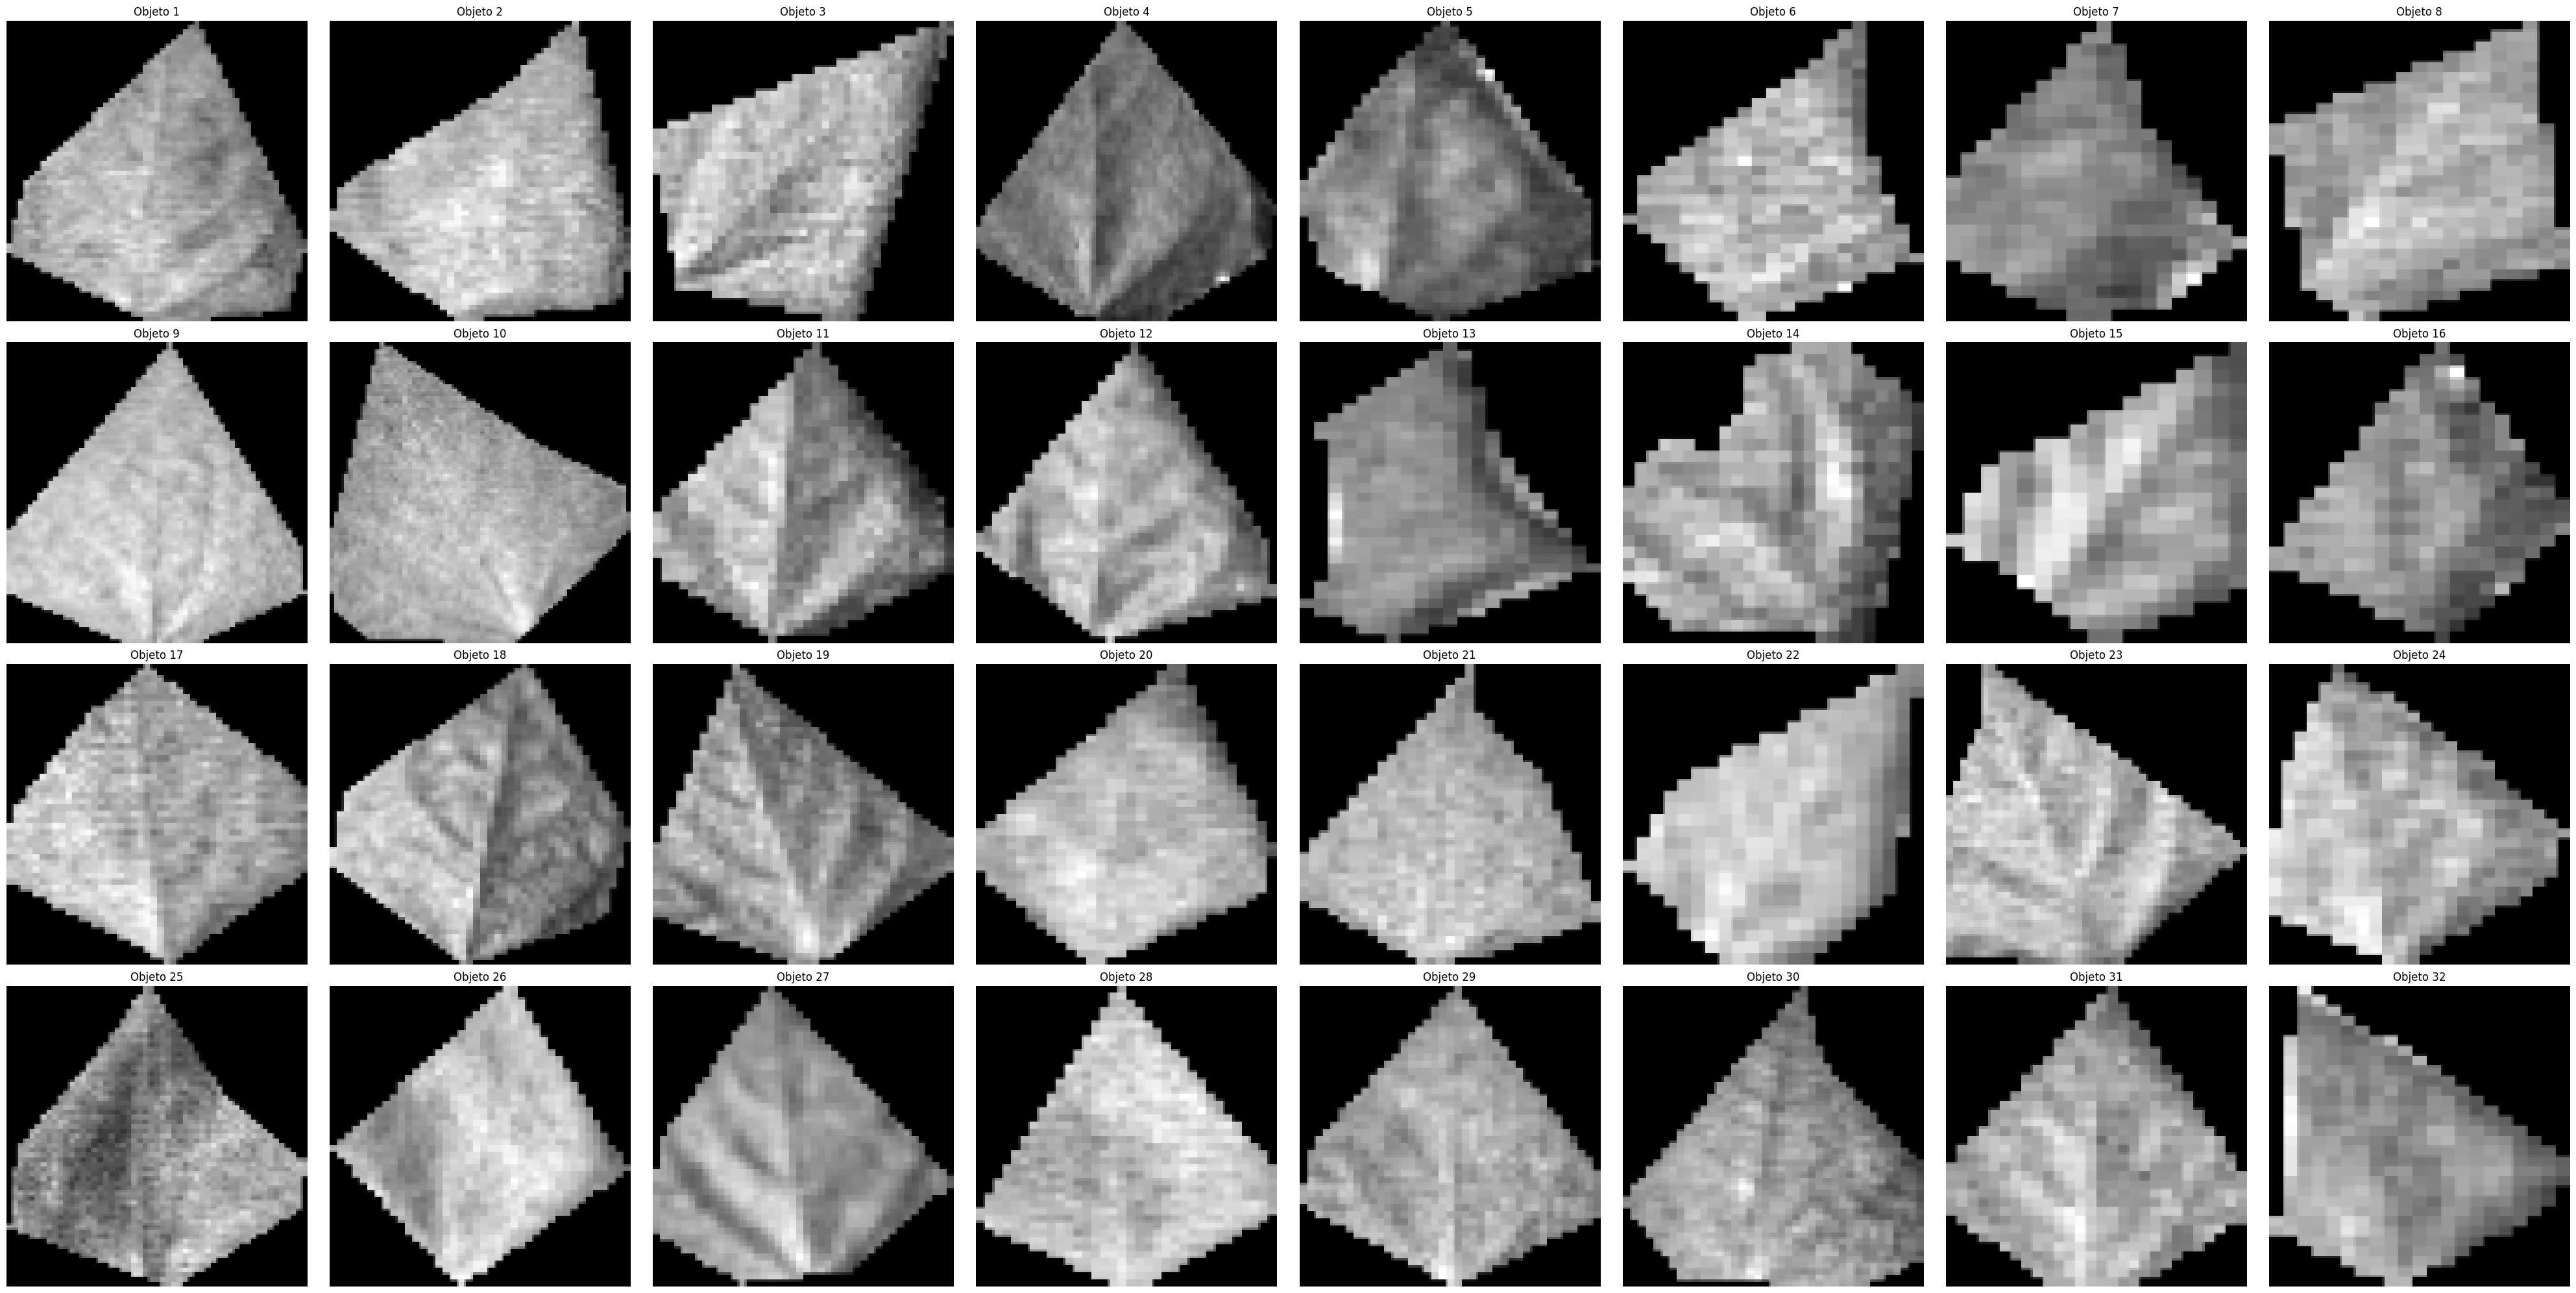

In [15]:
data, labels, centroids, num_labels, recortes = calcular_posiciones_relativas(
    imagen_base_mask, save_dir="recortes", original_img=imagen
)

# Visualización clásica con puntos
visualizar_objetos_centrados(data, num_labels)

# Nueva visualización con imágenes reales recortadas
visualizar_recortes(recortes)

In [14]:
imagen_base = maiz_imagen_base
imagen_base_mask = maiz_imagen_base_mask

imagen = imagen_base[:,:,0]
mask = imagen_base_mask

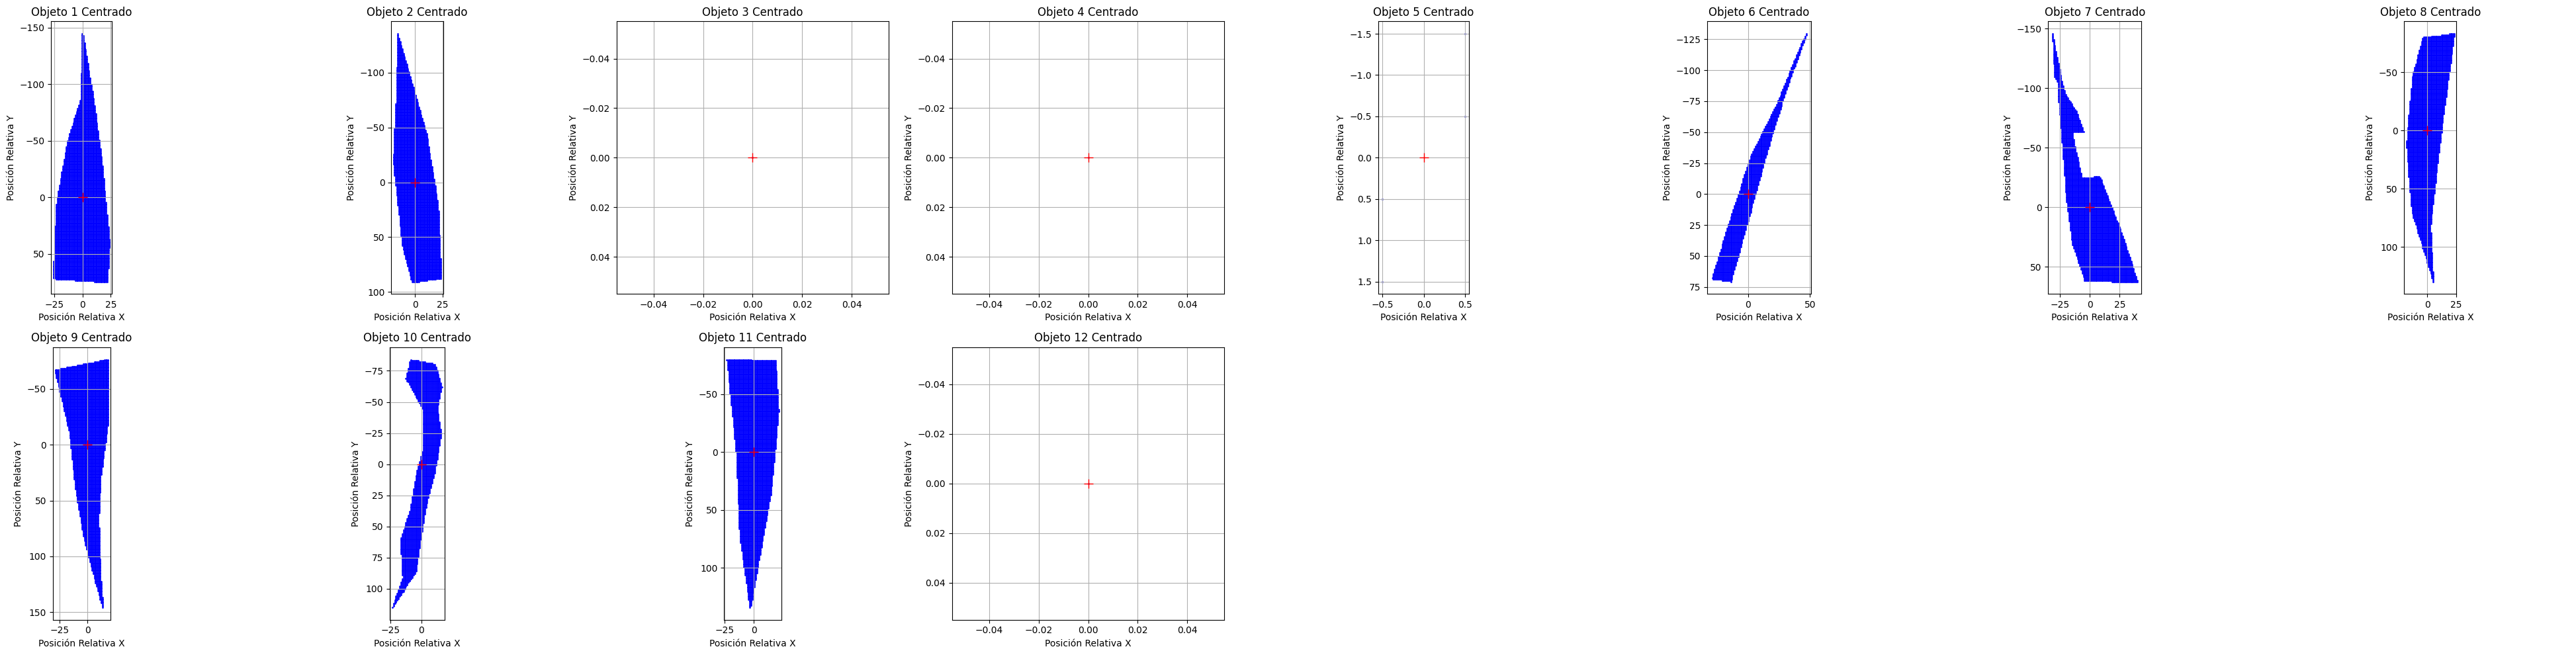

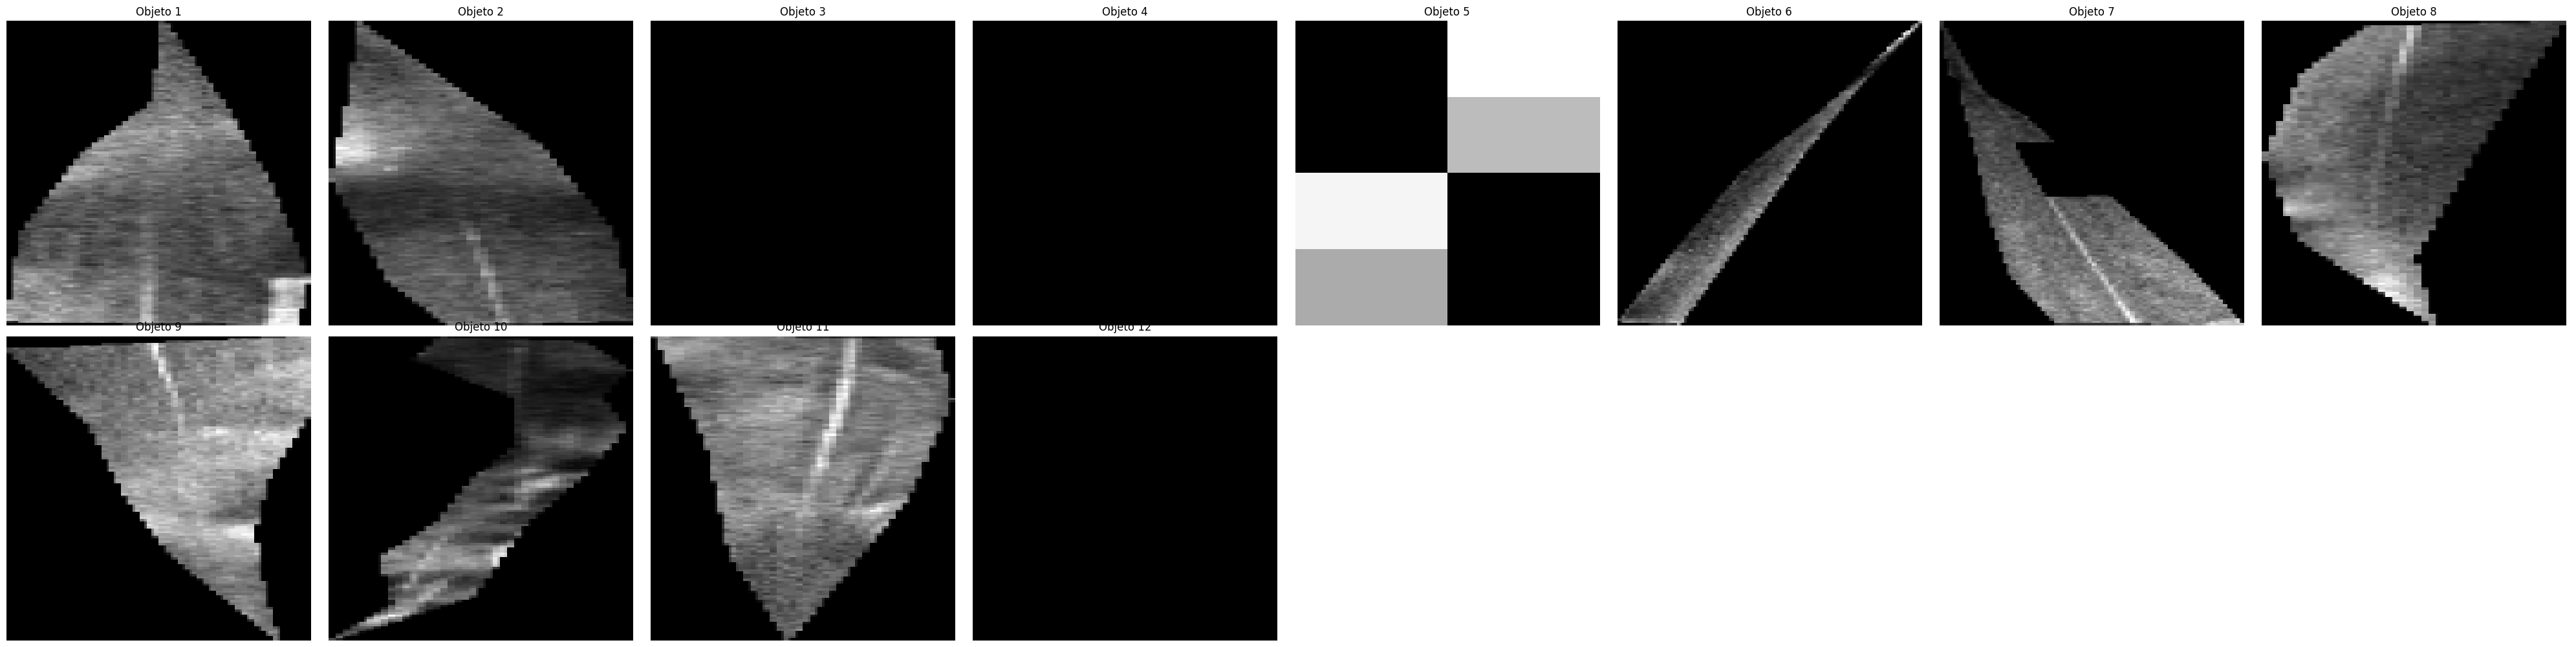

In [15]:
data, labels, centroids, num_labels, recortes = calcular_posiciones_relativas(
    imagen_base_mask, save_dir="recortes", original_img=imagen
)

# Visualización clásica con puntos
visualizar_objetos_centrados(data, num_labels)

# Nueva visualización con imágenes reales recortadas
visualizar_recortes(recortes)

### 3.1.2 Método 2: Recorte con canvas centrado

Coloca cada objeto en un canvas de tamaño fijo, centrando el objeto por su centroide

In [16]:
def calcular_posiciones_relativas(mask: np.ndarray, save_dir: str = None, original_img: np.ndarray = None, out_size: tuple = (128, 128)):
    """
    Encuentra objetos en una máscara binaria, calcula posiciones relativas
    y guarda los objetos en un canvas estándar centrados en su centroide.

    Args:
        mask (np.ndarray): Máscara binaria o en escala de grises.
        save_dir (str, optional): Carpeta donde guardar los recortes de objetos.
        original_img (np.ndarray, optional): Imagen original en gris o RGB.
        out_size (tuple, optional): Tamaño final del canvas (w, h).

    Returns:
        tuple: (posiciones_relativas_por_objeto, labels_matrix, centroids, num_labels, recortes)
    """
    _, mask_bin = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

    num_labels, labels_matrix, stats, centroids = cv2.connectedComponentsWithStats(
        mask_bin, connectivity=8, ltype=cv2.CV_32S)

    posiciones_relativas_por_objeto = {}
    recortes = {}

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    W, H = out_size
    center_x, center_y = W // 2, H // 2

    for i in range(1, num_labels):  
        cx, cy = centroids[i]
        pixeles_y, pixeles_x = np.where(labels_matrix == i)

        rel_x = pixeles_x - cx
        rel_y = pixeles_y - cy
        posiciones_relativas = np.vstack((rel_x, rel_y)).T
        posiciones_relativas_por_objeto[i] = posiciones_relativas

        # Recorte del objeto
        x, y, w, h, area = stats[i]
        objeto_mask = mask_bin[y:y+h, x:x+w]

        if original_img is not None:
            objeto_img = original_img[y:y+h, x:x+w]
            objeto_img = cv2.bitwise_and(objeto_img, objeto_img, mask=objeto_mask)
        else:
            objeto_img = objeto_mask

        # Normalizar rango
        if objeto_img.max() > 0:
            objeto_img = (objeto_img / objeto_img.max()) * 255
        objeto_img = objeto_img.astype(np.uint8)

        # --- Crear canvas centrado ---
        canvas = np.zeros((H, W), dtype=np.uint8)

        # Centroide relativo al recorte
        local_cx = cx - x
        local_cy = cy - y

        # Offset para colocar el centroide en el centro del canvas
        offset_x = int(center_x - local_cx)
        offset_y = int(center_y - local_cy)

        # Calcular las posiciones donde copiar
        y1 = max(0, offset_y)
        y2 = min(H, offset_y + objeto_img.shape[0])
        x1 = max(0, offset_x)
        x2 = min(W, offset_x + objeto_img.shape[1])

        # Rango del objeto
        obj_y1 = max(0, -offset_y)
        obj_y2 = obj_y1 + (y2 - y1)
        obj_x1 = max(0, -offset_x)
        obj_x2 = obj_x1 + (x2 - x1)

        # Copiar al canvas
        canvas[y1:y2, x1:x2] = objeto_img[obj_y1:obj_y2, obj_x1:obj_x2]

        recortes[i] = canvas

        if save_dir is not None:
            filename = os.path.join(save_dir, f"objeto_{i}.png")
            cv2.imwrite(filename, canvas)

    return posiciones_relativas_por_objeto, labels_matrix, centroids, num_labels, recortes


def visualizar_recortes(recortes, cols=8):
    """Visualización: muestra los recortes centrados en canvas fijo"""
    num_objetos = len(recortes)
    filas = int(np.ceil(num_objetos / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(3 * cols, 3 * filas))
    axes = np.array(axes).reshape(-1)

    for i, (label_id, img) in enumerate(recortes.items()):
        ax = axes[i]
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Objeto {label_id}")
        ax.axis("off")

    for j in range(num_objetos, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

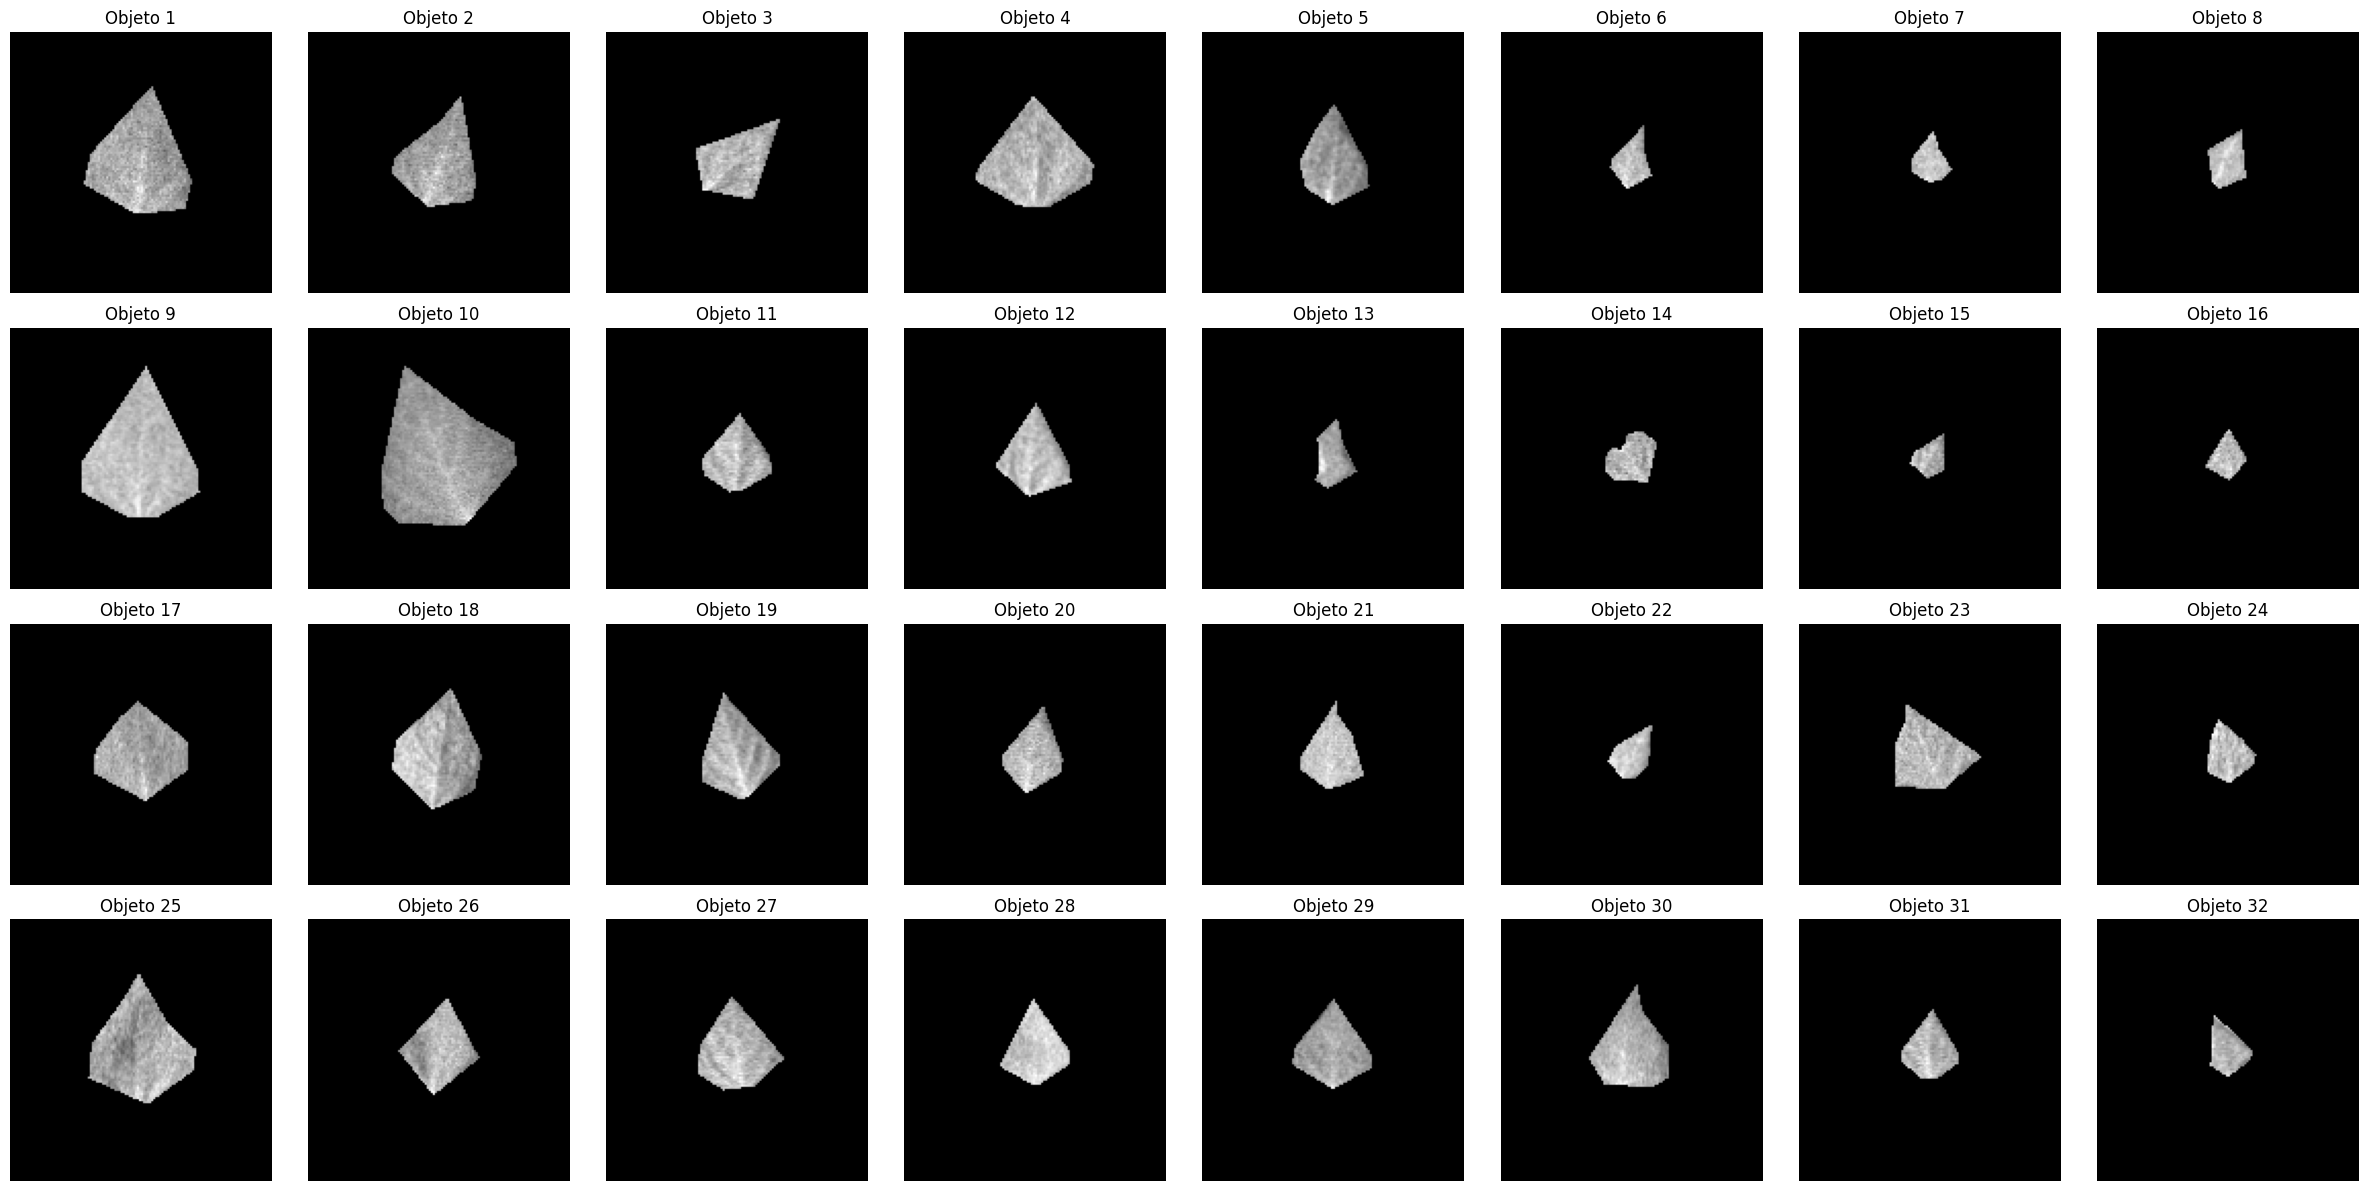

In [16]:
data, labels, centroids, num_labels, recortes = calcular_posiciones_relativas(
    frijol_imagen_base_mask, save_dir="recortes_canvas", original_img=frijol_original_image_array, out_size=(128, 128)
)

# Visualizar los objetos centrados en canvas
visualizar_recortes(recortes)

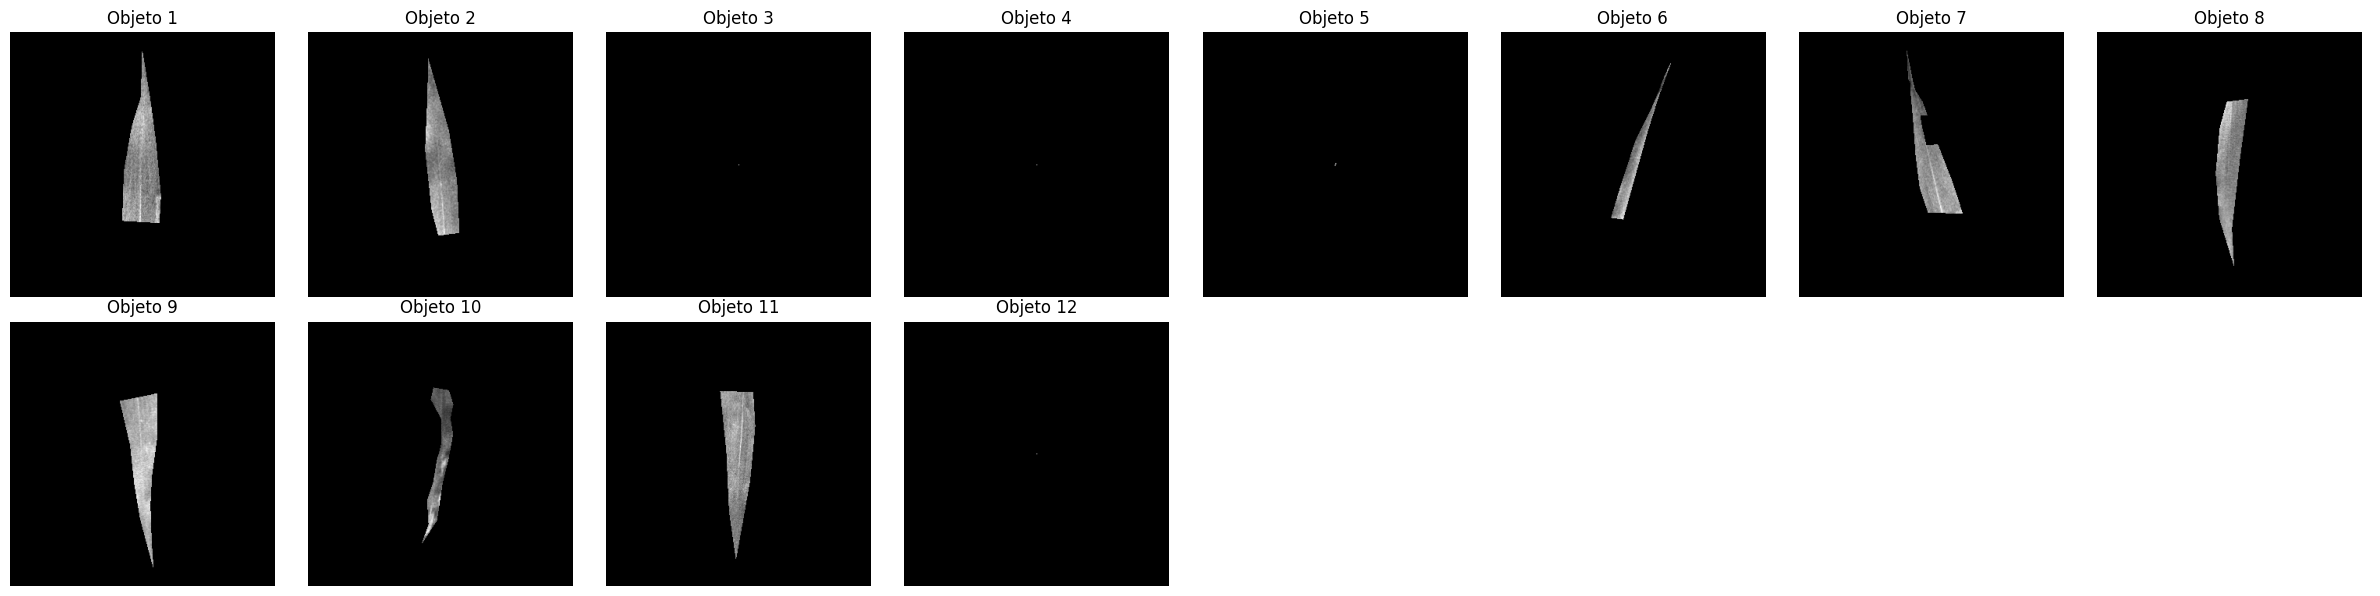

In [21]:
data, labels, centroids, num_labels, recortes = calcular_posiciones_relativas(
    maiz_imagen_base_mask, save_dir="recortes_canvas", original_img=maiz_original_image_array, out_size=(340, 340)
)

# Visualizar los objetos centrados en canvas
visualizar_recortes(recortes)

### 3.1.3 Método 3: Recorte con margen adicional

Añade margen alrededor del bounding box para evitar cortes en los bordes

In [17]:
def extraer_objetos_y_guardar_con_margen(mask, original_img, output_dir, size=128, margin=5, margin_pct=None):
    """
    Extrae objetos de una máscara binaria y los guarda centrados en un canvas cuadrado,
    aplicando un margen extra al bounding box para evitar cortes.

    Args:
        mask: imagen binaria (0 y 255) con los objetos.
        original_img: imagen original (grayscale o RGB).
        output_dir: carpeta donde se guardarán los recortes.
        size: tamaño de salida (ej. 128x128).
        margin: margen fijo en píxeles alrededor del bounding box.
        margin_pct: si se define, se ignora 'margin' y se usa un porcentaje del tamaño del objeto.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Etiquetado de componentes
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    for i in range(1, num_labels):  # ignorar fondo
        x, y, w, h, area = stats[i]

        # --- Calcular margen ---
        if margin_pct is not None:
            margin_x = int(w * margin_pct)
            margin_y = int(h * margin_pct)
        else:
            margin_x = margin_y = margin

        # --- Aplicar margen al bounding box ---
        x = max(0, x - margin_x)
        y = max(0, y - margin_y)
        w = min(mask.shape[1] - x, w + 2 * margin_x)
        h = min(mask.shape[0] - y, h + 2 * margin_y)

        # Máscara del objeto
        objeto_mask = (labels == i).astype(np.uint8) * 255
        objeto_crop_mask = objeto_mask[y:y+h, x:x+w]

        # Recorte de la imagen original
        if len(original_img.shape) == 2:  # Grayscale
            objeto_crop = original_img[y:y+h, x:x+w]
            objeto_crop = cv2.bitwise_and(objeto_crop, objeto_crop, mask=objeto_crop_mask)
        else:  # RGB
            objeto_crop = original_img[y:y+h, x:x+w]
            objeto_crop = cv2.bitwise_and(objeto_crop, objeto_crop, mask=objeto_crop_mask)

        # Normalizar rango
        if objeto_crop.max() > 0:
            objeto_crop = (objeto_crop / objeto_crop.max()) * 255
        objeto_crop = objeto_crop.astype(np.uint8)

        # --- Canvas cuadrado centrado ---
        canvas = np.zeros((size, size), dtype=np.uint8) if len(original_img.shape) == 2 else np.zeros((size, size, 3), dtype=np.uint8)

        # Redimensionar el objeto proporcionalmente
        h_obj, w_obj = objeto_crop.shape[:2]
        scale = min(size / w_obj, size / h_obj)
        new_w, new_h = int(w_obj * scale), int(h_obj * scale)
        objeto_resized = cv2.resize(objeto_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)

        # Colocar en el centro del canvas
        x_offset = (size - new_w) // 2
        y_offset = (size - new_h) // 2
        canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = objeto_resized

        # Guardar
        filename = os.path.join(output_dir, f"objeto_{i}.png")
        cv2.imwrite(filename, canvas)


In [18]:
extraer_objetos_y_guardar_con_margen(frijol_imagen_base_mask, imagen, "recorte_canvas_margin", size=128, margin_pct=0.2)

### 3.1.4 Método final: Extracción con contornos y canvas

Método usando `findContours` con margen porcentual y centrado por centroide

In [19]:
def extraer_objetos_por_contornos(
    mask,
    original_img=None,
    output_dir=None,
    size=128,
    margin=5,
    margin_pct=None,
    min_area=10,
    save=True
):
    """
    Extrae objetos individuales usando detección de contornos y los centra en un canvas.
    
    Args:
        mask: Máscara binaria (0/255)
        original_img: Imagen original (grayscale o BGR). Si None, usa la máscara
        output_dir: Carpeta para guardar recortes
        size: Tamaño del canvas de salida (size × size)
        margin: Margen fijo en píxeles
        margin_pct: Margen porcentual (anula margin si se define)
        min_area: Área mínima del contorno para considerar
        save: Si guardar imágenes en disco
    
    Returns:
        recortes: dict {idx: canvas_image} con imágenes uint8 [0-255]
        meta: lista de dicts con información (bbox, centroid, area, filename)
    """
    if mask is None:
        raise ValueError("La máscara no puede ser None.")
    
    # Binarizar máscara
    _, mask_bin = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)
    H_img, W_img = mask_bin.shape[:2]

    # Encontrar contornos externos
    contours_info = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = contours_info[0] if len(contours_info) == 2 else contours_info[1]

    if output_dir is not None and save:
        os.makedirs(output_dir, exist_ok=True)

    recortes = {}
    meta = []
    center_coord = (size // 2, size // 2)

    for idx, cnt in enumerate(contours, start=1):
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue  # Ignorar ruido

        # Bounding box del contorno
        x, y, w, h = cv2.boundingRect(cnt)

        # Calcular margen
        if margin_pct is not None:
            m_x = int(w * margin_pct)
            m_y = int(h * margin_pct)
        else:
            m_x = m_y = int(margin)

        # Aplicar margen con límites de imagen
        x0 = max(0, x - m_x)
        y0 = max(0, y - m_y)
        x1 = min(W_img, x + w + m_x)
        y1 = min(H_img, y + h + m_y)

        w_crop = x1 - x0
        h_crop = y1 - y0
        if w_crop <= 0 or h_crop <= 0:
            continue

        # Crear máscara local del contorno
        mask_local = np.zeros((h_crop, w_crop), dtype=np.uint8)
        cnt_local = cnt.copy() - np.array([[x0, y0]])
        cv2.drawContours(mask_local, [cnt_local], -1, 255, thickness=-1)

        # Extraer recorte de imagen
        if original_img is None:
            img_crop = mask_local.copy()
        else:
            img_crop = original_img[y0:y1, x0:x1].copy()
            img_crop = cv2.bitwise_and(img_crop, img_crop, mask=mask_local)

        if img_crop.size == 0 or mask_local.sum() == 0:
            continue

        # Normalizar a [0-255]
        if img_crop.dtype != np.uint8:
            maxv = img_crop.max() if img_crop.max() > 0 else 1.0
            img_crop = (img_crop.astype(np.float32) / float(maxv) * 255.0).astype(np.uint8)

        h_obj, w_obj = img_crop.shape[:2]

        # Calcular escala para ajustar al canvas
        scale = min(size / w_obj, size / h_obj)
        new_w = max(1, int(round(w_obj * scale)))
        new_h = max(1, int(round(h_obj * scale)))

        # Redimensionar
        if (new_w, new_h) != (w_obj, h_obj):
            img_resized = cv2.resize(img_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
            mask_resized = cv2.resize(mask_local, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        else:
            img_resized = img_crop
            mask_resized = mask_local

        # Calcular centroide para centrar en canvas
        M = cv2.moments(cnt)
        if M.get("m00", 0) != 0:
            cx_abs = M["m10"] / M["m00"]
            cy_abs = M["m01"] / M["m00"]
        else:
            cx_abs = x + w / 2.0
            cy_abs = y + h / 2.0

        # Centroide local y escalado
        local_cx = (cx_abs - x0)
        local_cy = (cy_abs - y0)
        scaled_local_cx = local_cx * (new_w / w_obj)
        scaled_local_cy = local_cy * (new_h / h_obj)

        # Crear canvas
        if original_img is None:
            canvas = np.zeros((size, size), dtype=np.uint8)
        else:
            if original_img.ndim == 2:
                canvas = np.zeros((size, size), dtype=np.uint8)
            else:
                channels = original_img.shape[2]
                canvas = np.zeros((size, size, channels), dtype=np.uint8)

        # Calcular offset para centrar
        center_x, center_y = center_coord
        offset_x = int(round(center_x - scaled_local_cx))
        offset_y = int(round(center_y - scaled_local_cy))

        # Coordenadas en canvas
        y1_c = max(0, offset_y)
        y2_c = min(size, offset_y + new_h)
        x1_c = max(0, offset_x)
        x2_c = min(size, offset_x + new_w)

        # Coordenadas en objeto
        obj_y1 = max(0, -offset_y)
        obj_y2 = obj_y1 + (y2_c - y1_c)
        obj_x1 = max(0, -offset_x)
        obj_x2 = obj_x1 + (x2_c - x1_c)

        if (y2_c - y1_c) <= 0 or (x2_c - x1_c) <= 0:
            continue

        # Pegar en canvas
        if img_resized.ndim == 2:
            canvas[y1_c:y2_c, x1_c:x2_c] = img_resized[obj_y1:obj_y2, obj_x1:obj_x2]
        else:
            canvas[y1_c:y2_c, x1_c:x2_c, :] = img_resized[obj_y1:obj_y2, obj_x1:obj_x2, :]

        # Guardar archivo
        filename = None
        if save and output_dir is not None:
            filename = os.path.join(output_dir, f"objeto_cnt_{idx}.png")
            cv2.imwrite(filename, canvas)

        recortes[idx] = canvas
        meta.append({
            "idx": idx,
            "bbox": (x0, y0, w_crop, h_crop),
            "centroid": (cx_abs, cy_abs),
            "area": area,
            "filename": filename
        })

    return recortes, meta


def visualizar_recortes(recortes, cols=8, cmap="gray"):
    """Visualiza recortes en rejilla."""
    num = len(recortes)
    if num == 0:
        print("No hay recortes para mostrar.")
        return
    filas = int(np.ceil(num / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(3 * cols, 3 * filas))
    axes = np.array(axes).reshape(-1)
    for i, (k, img) in enumerate(recortes.items()):
        ax = axes[i]
        if img.ndim == 2:
            ax.imshow(img, cmap=cmap)
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{k}")
        ax.axis("off")
    for j in range(num, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

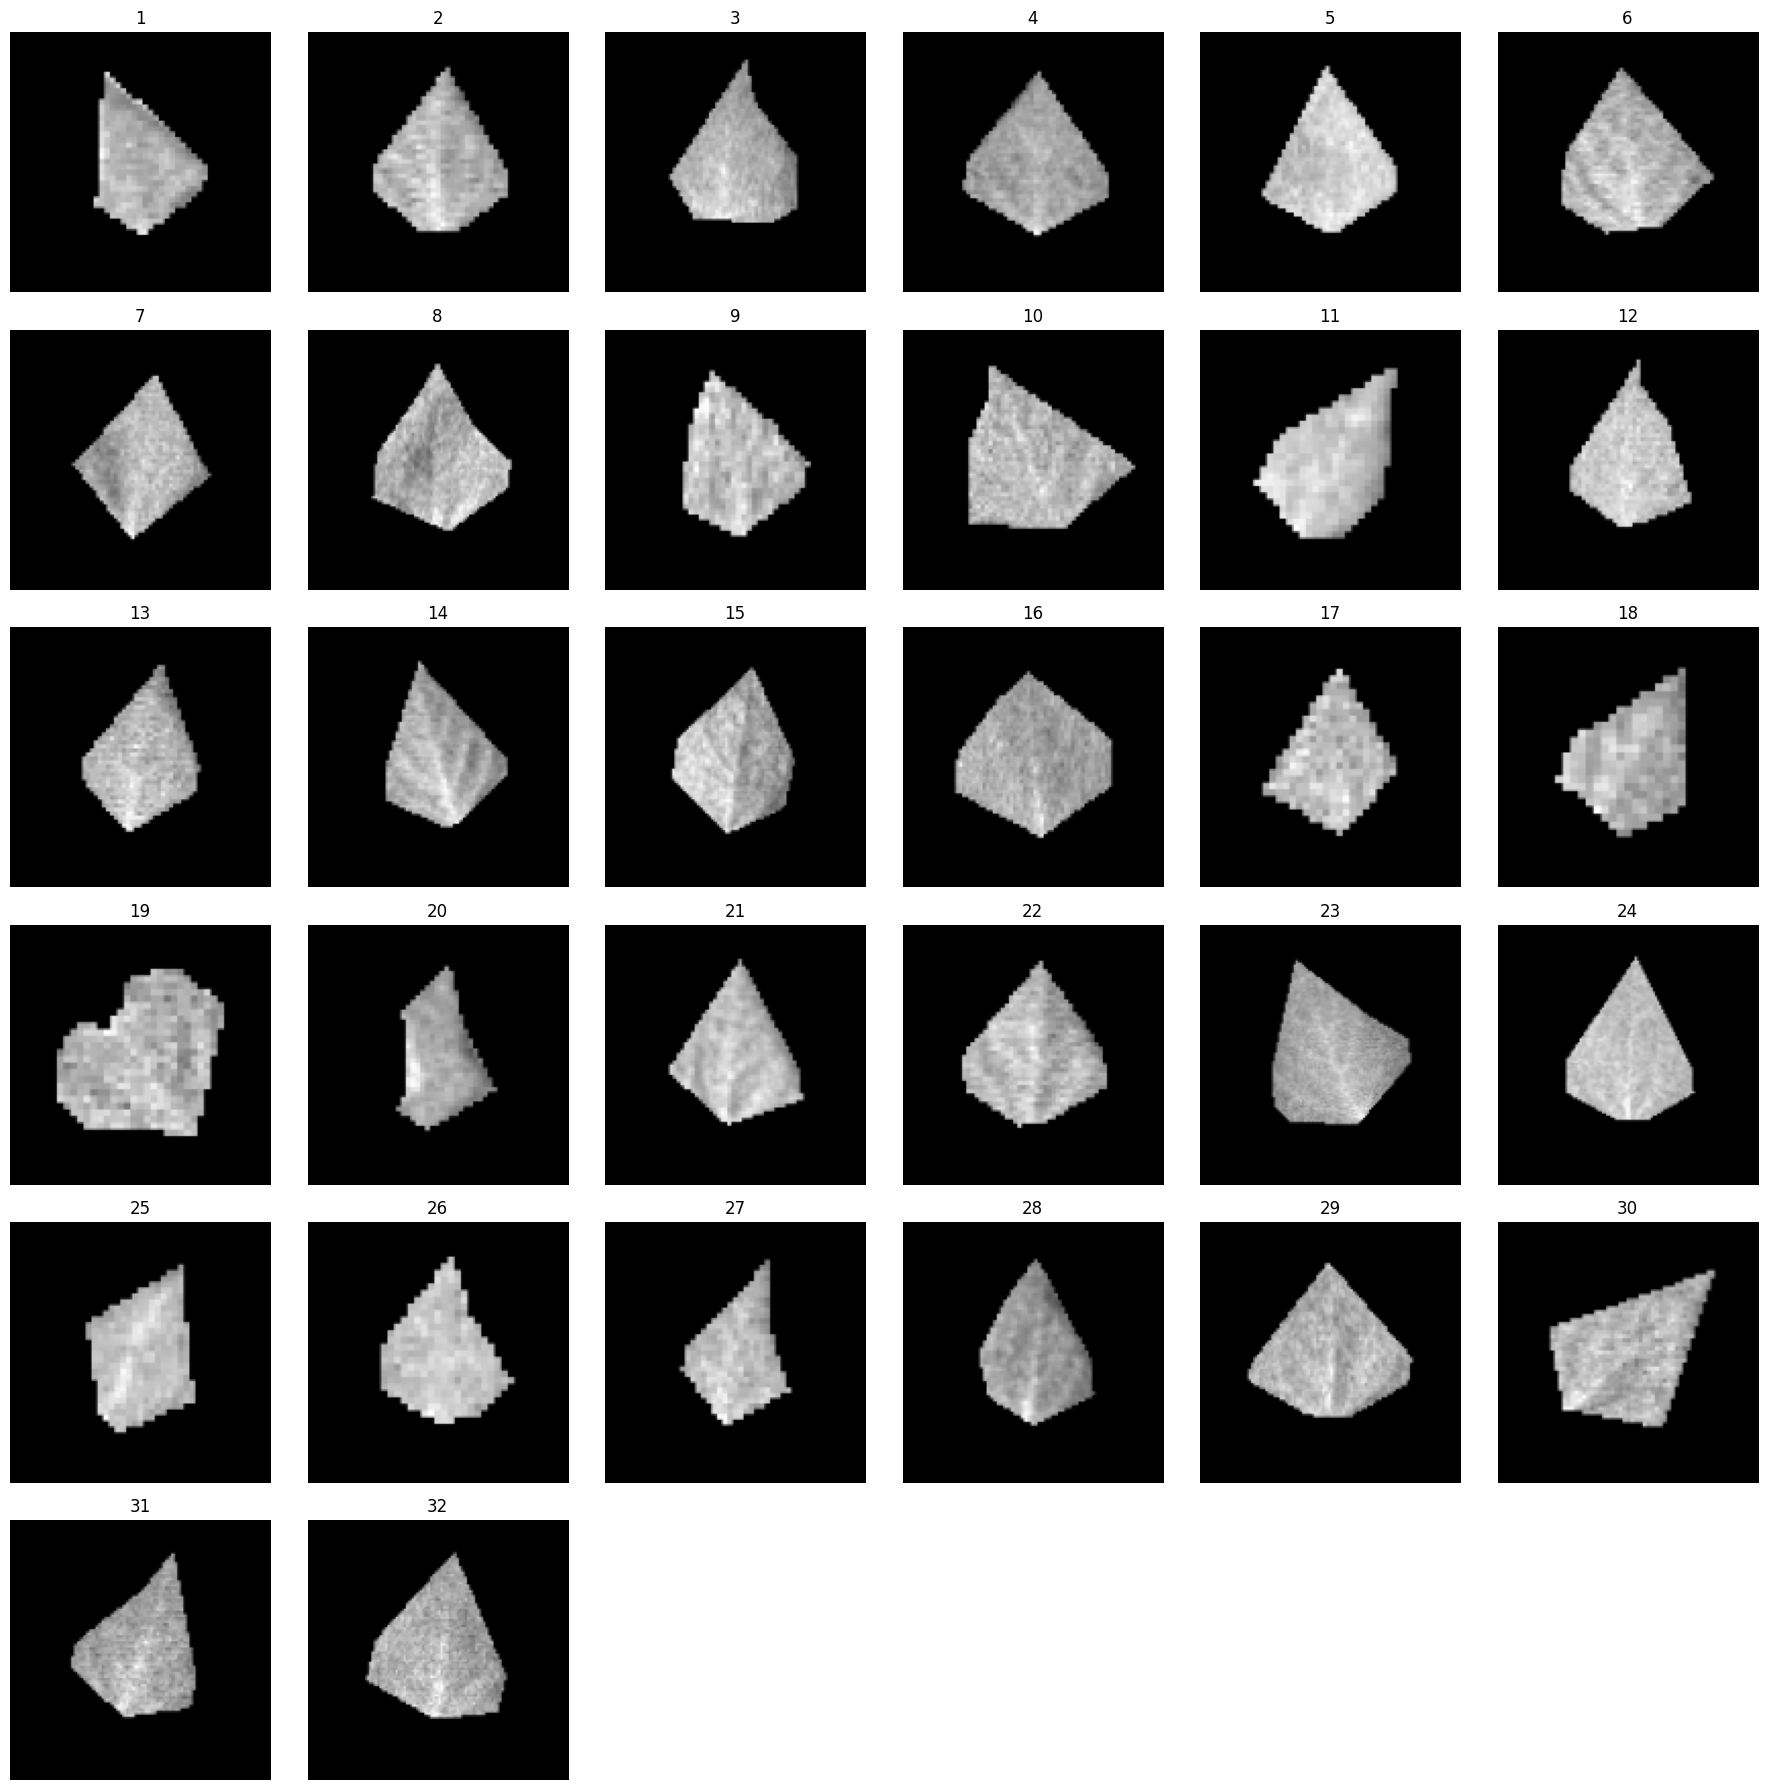

In [20]:
# Ejemplo de extracción para fríjol
recortes, meta = extraer_objetos_por_contornos(
    frijol_imagen_base_mask,
    original_img=frijol_original_image_array,
    output_dir="salida_contours",
    size=128,
    margin=20,
    margin_pct=0.3,  # 30% de margen adicional
    min_area=20,
    save=True
)

visualizar_recortes(recortes, cols=6)

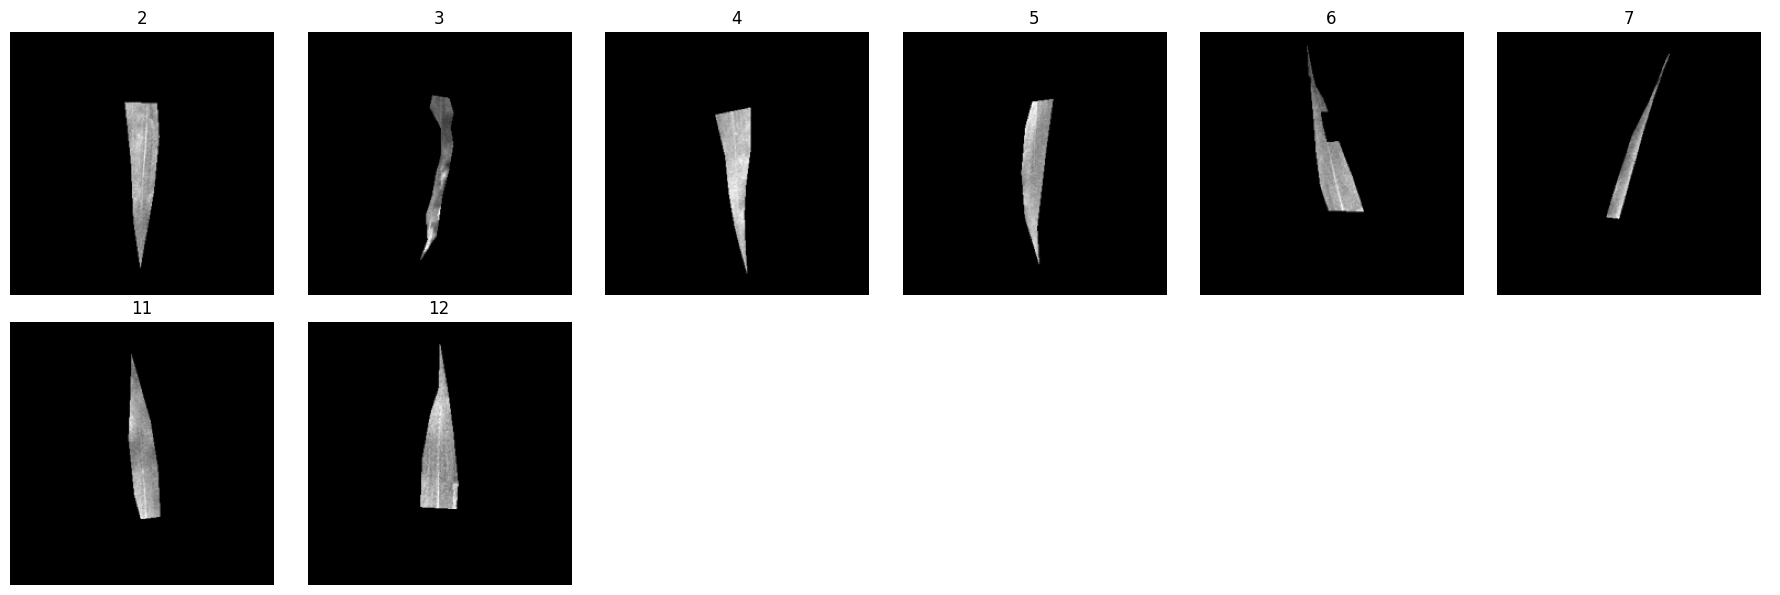

In [ ]:
# Ejemplo de extracción para maíz (requiere canvas más grande)
recortes, meta = extraer_objetos_por_contornos(
    maiz_imagen_base_mask,
    original_img=maiz_original_image_array,
    output_dir="salida_contours",
    size=240,  # Canvas más grande para hojas de maíz
    margin=20,
    margin_pct=0.3,
    min_area=20,
    save=True
)

visualizar_recortes(recortes, cols=6)

## 3.2 Procesamiento masivo: Separar hojas por tratamiento

Procesar todos los archivos .mat organizándolos por tratamiento y banda espectral

In [15]:
def cargar_imagen_mat(filepath):
    """
    Carga la imagen multiespectral desde archivo .mat.
    
    Args:
        filepath: Ruta al archivo .mat
    
    Returns:
        Array 3D con la imagen (clave 'R')
    """
    mat_data = loadmat(filepath)
    return mat_data['R']

In [16]:
def cargar_mask_mat(filepath):
    """
    Carga la máscara de segmentación desde archivo .mat.
    
    Args:
        filepath: Ruta al archivo .mat
    
    Returns:
        Array 2D con la máscara (clave 'class_map')
    """
    mat_class_data = loadmat(filepath)
    return mat_class_data['class_map']

### 3.2.1 Procesamiento de fríjol

In [17]:
# Longitudes de onda de las 10 bandas espectrales (nm)
longitudes_de_onda = [444, 475, 531, 560, 650, 668, 705, 717, 740, 848]

In [18]:
def construir_objetos_desde_mask(mask: np.ndarray, min_area: float = 20, opening_kernel: int = 3):
    """Construye objetos por class_id usando componentes conectados con IDs estables."""
    class_ids = np.unique(mask)
    class_ids = class_ids[class_ids != 0]

    objetos = []

    for class_id in np.sort(class_ids):
        class_mask = (mask == class_id).astype(np.uint8) * 255

        if opening_kernel and opening_kernel > 1:
            kernel = np.ones((opening_kernel, opening_kernel), np.uint8)
            class_mask = cv2.morphologyEx(class_mask, cv2.MORPH_OPEN, kernel)

        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            class_mask, connectivity=8, ltype=cv2.CV_32S
        )

        for i in range(1, num_labels):
            area = float(stats[i, cv2.CC_STAT_AREA])
            if area < float(min_area):
                continue

            pixels_y, pixels_x = np.where(labels == i)
            if len(pixels_x) == 0:
                continue

            objetos.append(
                {
                    "class_id": int(class_id),
                    "pixels_x": pixels_x,
                    "pixels_y": pixels_y,
                    "cx": float(centroids[i][0]),
                    "cy": float(centroids[i][1]),
                }
            )

    objetos = sorted(objetos, key=lambda o: (o["cy"], o["cx"], o["class_id"]))
    for idx, obj in enumerate(objetos, start=1):
        obj["object_local_id"] = idx

    return objetos


def construir_split_objetos(object_ids, train_ratio: float = 0.7, seed: int = 42):
    """Genera split train/test por IDs únicos de objeto."""
    object_ids_unicos = sorted(set(object_ids))
    if not object_ids_unicos:
        return {}

    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(object_ids_unicos))
    n_train = int(round(len(object_ids_unicos) * float(train_ratio)))
    n_train = max(1, min(n_train, len(object_ids_unicos) - 1)) if len(object_ids_unicos) > 1 else 1

    split_map = {}
    for rank, idx in enumerate(perm):
        obj_id = object_ids_unicos[idx]
        split_map[obj_id] = "train" if rank < n_train else "test"

    return split_map


def extraer_objeto_en_canvas_por_pixeles(original_img, pixels_x, pixels_y, size=128, margin=20, margin_pct=0.3):
    """Recorta un objeto por sus píxeles y lo centra en un canvas cuadrado."""
    H, W = original_img.shape[:2]

    x_min, x_max = int(np.min(pixels_x)), int(np.max(pixels_x))
    y_min, y_max = int(np.min(pixels_y)), int(np.max(pixels_y))

    w_obj = x_max - x_min + 1
    h_obj = y_max - y_min + 1

    if margin_pct is not None:
        margin_x = int(round(w_obj * float(margin_pct)))
        margin_y = int(round(h_obj * float(margin_pct)))
    else:
        margin_x = margin_y = int(margin)

    x0 = max(0, x_min - margin_x)
    y0 = max(0, y_min - margin_y)
    x1 = min(W, x_max + margin_x + 1)
    y1 = min(H, y_max + margin_y + 1)

    crop = original_img[y0:y1, x0:x1].copy()
    if crop.size == 0:
        return None

    local_h, local_w = crop.shape[:2]
    local_mask = np.zeros((local_h, local_w), dtype=np.uint8)
    local_mask[pixels_y - y0, pixels_x - x0] = 255

    crop = cv2.bitwise_and(crop, crop, mask=local_mask)

    if crop.dtype != np.uint8:
        maxv = float(crop.max()) if crop.max() > 0 else 1.0
        crop = (crop.astype(np.float32) / maxv * 255.0).astype(np.uint8)

    h_crop, w_crop = crop.shape[:2]
    if h_crop == 0 or w_crop == 0:
        return None

    scale = min(size / w_crop, size / h_crop)
    new_w = max(1, int(round(w_crop * scale)))
    new_h = max(1, int(round(h_crop * scale)))

    resized = cv2.resize(crop, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((size, size), dtype=np.uint8)
    x_offset = (size - new_w) // 2
    y_offset = (size - new_h) // 2
    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    return canvas


def extraer_objetos_organizados_por_split(
    image,
    mask,
    split_map,
    base_dir,
    img_filename,
    treatment,
    banda,
    cultivo,
    min_area=20,
    opening_kernel=3,
):
    """Extrae objetos y los guarda en train/test conservando el mismo split por objeto."""
    objetos = construir_objetos_desde_mask(mask, min_area=min_area, opening_kernel=opening_kernel)
    size = 128 if cultivo == "frijol" else 240

    for obj in objetos:
        object_id = f"{img_filename}__obj_{obj['object_local_id']:03d}"
        split = split_map.get(object_id, "train")

        split_dir = os.path.join(base_dir, split, f"T{treatment}", f"{img_filename}_banda_{banda}")
        os.makedirs(split_dir, exist_ok=True)

        canvas = extraer_objeto_en_canvas_por_pixeles(
            original_img=image,
            pixels_x=obj["pixels_x"],
            pixels_y=obj["pixels_y"],
            size=size,
            margin=20,
            margin_pct=0.3,
        )

        if canvas is None:
            continue

        filename = os.path.join(split_dir, f"{object_id}.png")
        cv2.imwrite(filename, canvas)

    return len(objetos)

In [19]:
# Configuración de rutas
ruta_principal = "data/mat"
cultivo = "frijol"
ruta_cultivo = os.path.join(ruta_principal, cultivo)
base_output_dir = f"extracted_objects_{cultivo}_split"
output_split_manifest = f"datasets/object_split_{cultivo}_images.csv"

if os.path.isdir(base_output_dir):
    shutil.rmtree(base_output_dir)

# Patrón para extraer número de tratamiento del nombre de archivo
treatment_pattern = re.compile(r"_T(\d+)")

SPLIT_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15


def construir_split_hojas_estratificado(records, train_ratio=0.7, val_ratio=0.15, seed=42):
    """
    Split por hoja (object_id) estratificado por tratamiento.
    Regla: si un tratamiento tiene >=3 hojas, fuerza al menos 1 en train, 1 en val y 1 en test.
    """
    if not records:
        return {}

    hojas_por_trat = {}
    for rec in records:
        tr = int(rec["tratamiento"])
        hojas_por_trat.setdefault(tr, set()).add(rec["object_id"])

    split_map = {}
    rng = np.random.default_rng(seed)

    for tr in sorted(hojas_por_trat.keys()):
        ids = sorted(hojas_por_trat[tr])
        n = len(ids)
        if n == 0:
            continue

        perm = rng.permutation(n)
        ids_perm = [ids[i] for i in perm]

        n_train = int(np.floor(n * float(train_ratio)))
        n_val = int(np.floor(n * float(val_ratio)))
        n_test = n - n_train - n_val

        if n >= 3:
            if n_train == 0:
                n_train = 1
            if n_val == 0:
                n_val = 1
            n_test = n - n_train - n_val
            if n_test == 0:
                if n_train >= n_val and n_train > 1:
                    n_train -= 1
                elif n_val > 1:
                    n_val -= 1
                n_test = n - n_train - n_val

        n_train = max(0, n_train)
        n_val = max(0, n_val)
        n_test = max(0, n_test)

        for i, object_id in enumerate(ids_perm):
            if i < n_train:
                split = "train"
            elif i < n_train + n_val:
                split = "val"
            else:
                split = "test"
            split_map[object_id] = split

        print(f"Tratamiento T{tr}: total_hojas={n} -> train={n_train}, val={n_val}, test={n_test}")

    return split_map


print("\nPasada 1: recolectar object_ids por hoja")
image_records = []
object_records = []

for fecha in os.listdir(ruta_cultivo):
    ruta_fecha = os.path.join(ruta_cultivo, fecha)
    if not os.path.isdir(ruta_fecha):
        continue

    masks = sorted([f for f in os.listdir(ruta_fecha) if f.startswith("CLASS__") and f.endswith(".mat")])
    images = sorted([f for f in os.listdir(ruta_fecha) if f.startswith("REF__") and f.endswith(".mat")])

    for img_file, mask_file in zip(images, masks):
        img_path = os.path.join(ruta_fecha, img_file)
        mask_path = os.path.join(ruta_fecha, mask_file)

        nombre = os.path.splitext(img_file)[0]
        match = treatment_pattern.search(nombre)
        tratamiento_key = int(match.group(1)) if match else 0

        try:
            mask = cargar_mask_mat(mask_path)
            objetos = construir_objetos_desde_mask(mask, min_area=20, opening_kernel=3)
            object_ids = [f"{nombre}__obj_{obj['object_local_id']:03d}" for obj in objetos]

            image_records.append(
                {
                    "img_file": img_file,
                    "img_path": img_path,
                    "mask_path": mask_path,
                    "nombre": nombre,
                    "tratamiento": tratamiento_key,
                    "object_ids": object_ids,
                }
            )

            for obj_id in object_ids:
                object_records.append(
                    {
                        "object_id": obj_id,
                        "tratamiento": tratamiento_key,
                    }
                )
        except Exception as e:
            print(f"Error preparando split para {img_file}: {e}")

split_map = construir_split_hojas_estratificado(
    object_records,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SPLIT_SEED,
)

if not split_map:
    raise ValueError("No se encontraron hojas para construir el split de fríjol.")

manifest_rows = []
for rec in object_records:
    manifest_rows.append(
        {
            "tratamiento": rec["tratamiento"],
            "object_id": rec["object_id"],
            "split": split_map[rec["object_id"]],
        }
    )

split_manifest_df = pd.DataFrame(manifest_rows)
os.makedirs("datasets", exist_ok=True)
split_manifest_df.to_csv(output_split_manifest, index=False)

print(f"\nSplit por hoja ({cultivo}): {split_manifest_df['split'].value_counts().to_dict()}")
print("Resumen tratamientos por split (hojas):")
print(split_manifest_df.groupby(["split", "tratamiento"]).size())

print(f"\n🔹 Procesando cultivo: {cultivo}")

for rec in image_records:
    try:
        image = cargar_imagen_mat(rec["img_path"])
        mask = cargar_mask_mat(rec["mask_path"])

        for channel, banda in enumerate(longitudes_de_onda):
            if channel >= image.shape[2]:
                print(f"⚠️ Saltando banda {channel}, no existe en {rec['img_file']}.")
                continue

            base_image = image[:, :, channel]
            start_time = time.time()

            n_obj = extraer_objetos_organizados_por_split(
                image=base_image,
                mask=mask,
                split_map=split_map,
                base_dir=base_output_dir,
                img_filename=rec["nombre"],
                treatment=rec["tratamiento"],
                banda=banda,
                cultivo=cultivo,
                min_area=20,
                opening_kernel=3,
            )

            end_time = time.time()
            print(
                f"✅ Procesada {rec['img_file']}, banda {banda}nm | "
                f"objetos: {n_obj} | tiempo: {end_time-start_time:.2f}s"
            )

    except Exception as e:
        print(f"❌ Error cargando {rec['img_file']}: {e}")

print(f"Dataset de imágenes con split por hoja guardado en: {base_output_dir}")
print(f"Manifest split: {output_split_manifest}")


Pasada 1: recolectar object_ids por hoja
Tratamiento T1: total_hojas=96 -> train=67, val=14, test=15
Tratamiento T2: total_hojas=96 -> train=67, val=14, test=15
Tratamiento T3: total_hojas=96 -> train=67, val=14, test=15
Tratamiento T4: total_hojas=95 -> train=66, val=14, test=15

Split por hoja (frijol): {'train': 267, 'test': 60, 'val': 56}
Resumen tratamientos por split (hojas):
split  tratamiento
test   1              15
       2              15
       3              15
       4              15
train  1              67
       2              67
       3              67
       4              66
val    1              14
       2              14
       3              14
       4              14
dtype: int64

🔹 Procesando cultivo: frijol
✅ Procesada REF__0000_T2R1.mat, banda 444nm | objetos: 32 | tiempo: 0.87s
✅ Procesada REF__0000_T2R1.mat, banda 475nm | objetos: 32 | tiempo: 0.61s
✅ Procesada REF__0000_T2R1.mat, banda 531nm | objetos: 32 | tiempo: 0.49s
✅ Procesada REF__0000_T2R1.mat

### 3.2.2 Procesamiento de maíz

In [20]:
def extraer_genotipos(nombre_archivo: str):
    """
    Extrae IDs de genotipos del nombre de archivo.
    Patrón: ...R<repeticion>G<id>G<id>...
    
    Ejemplo: REF__0002_T1R1G10G4 -> [10, 4]
    
    Args:
        nombre_archivo: Nombre del archivo .mat
    
    Returns:
        Lista de IDs de genotipos (enteros)
    """
    base = os.path.splitext(nombre_archivo)[0]
    
    # Buscar patrón R<num>G<num>...
    m = re.search(r"R\d+((?:G\d+)+)$", base)
    if not m:
        gens = re.findall(r"G\d+", base)
    else:
        gens = re.findall(r"G\d+", m.group(1))
    
    return [int(g[1:]) for g in gens]

In [21]:
# Configuración de rutas para maíz
ruta_principal = "data/mat"
cultivo = "maiz"
ruta_cultivo = os.path.join(ruta_principal, cultivo)
base_output_dir = f"extracted_objects_{cultivo}_split"
output_split_manifest = f"datasets/object_split_{cultivo}_images.csv"

if os.path.isdir(base_output_dir):
    shutil.rmtree(base_output_dir)

treatment_pattern = re.compile(r"_T(\d+)")

SPLIT_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15


def construir_split_hojas_estratificado(records, train_ratio=0.7, val_ratio=0.15, seed=42):
    """Split por hoja (object_id) estratificado por tratamiento."""
    if not records:
        return {}

    hojas_por_trat = {}
    for rec in records:
        tr = int(rec["tratamiento"])
        hojas_por_trat.setdefault(tr, set()).add(rec["object_id"])

    split_map = {}
    rng = np.random.default_rng(seed)

    for tr in sorted(hojas_por_trat.keys()):
        ids = sorted(hojas_por_trat[tr])
        n = len(ids)
        if n == 0:
            continue

        perm = rng.permutation(n)
        ids_perm = [ids[i] for i in perm]

        n_train = int(np.floor(n * float(train_ratio)))
        n_val = int(np.floor(n * float(val_ratio)))
        n_test = n - n_train - n_val

        if n >= 3:
            if n_train == 0:
                n_train = 1
            if n_val == 0:
                n_val = 1
            n_test = n - n_train - n_val
            if n_test == 0:
                if n_train >= n_val and n_train > 1:
                    n_train -= 1
                elif n_val > 1:
                    n_val -= 1
                n_test = n - n_train - n_val

        n_train = max(0, n_train)
        n_val = max(0, n_val)
        n_test = max(0, n_test)

        for i, object_id in enumerate(ids_perm):
            if i < n_train:
                split = "train"
            elif i < n_train + n_val:
                split = "val"
            else:
                split = "test"
            split_map[object_id] = split

        print(f"Tratamiento T{tr}: total_hojas={n} -> train={n_train}, val={n_val}, test={n_test}")

    return split_map


# Pasada 1: recolectar object_ids por hoja
image_records = []
object_records = []

for fecha in os.listdir(ruta_cultivo):
    ruta_fecha = os.path.join(ruta_cultivo, fecha)
    if not os.path.isdir(ruta_fecha):
        continue

    masks = [f for f in os.listdir(ruta_fecha) if f.startswith("CLASS") and f.endswith(".mat")]
    images = [f for f in os.listdir(ruta_fecha) if f.startswith("REF") and f.endswith(".mat")]

    masks_dict = {}
    for m in masks:
        key = m.replace("CLASS__", "").replace("CLASS_", "")
        masks_dict[key] = m

    for img_file in sorted(images):
        img_key = img_file.replace("REF__", "").replace("REF_", "")
        mask_file = masks_dict.get(img_key)
        if mask_file is None:
            continue

        img_path = os.path.join(ruta_fecha, img_file)
        mask_path = os.path.join(ruta_fecha, mask_file)

        nombre = os.path.splitext(img_file)[0]
        match = treatment_pattern.search(nombre)
        tratamiento_key = int(match.group(1)) if match else 0

        try:
            mask = cargar_mask_mat(mask_path)
            objetos = construir_objetos_desde_mask(mask, min_area=20, opening_kernel=3)
            object_ids = [f"{nombre}__obj_{obj['object_local_id']:03d}" for obj in objetos]

            image_records.append(
                {
                    "img_file": img_file,
                    "img_path": img_path,
                    "mask_path": mask_path,
                    "nombre": nombre,
                    "tratamiento": tratamiento_key,
                    "object_ids": object_ids,
                }
            )

            for obj_id in object_ids:
                object_records.append(
                    {
                        "object_id": obj_id,
                        "tratamiento": tratamiento_key,
                    }
                )
        except Exception as e:
            print(f"Error preparando split para {img_file}: {e}")

split_map = construir_split_hojas_estratificado(
    object_records,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SPLIT_SEED,
)

if not split_map:
    raise ValueError("No se encontraron hojas para construir el split de maíz.")

manifest_rows = []
for rec in object_records:
    manifest_rows.append(
        {
            "tratamiento": rec["tratamiento"],
            "object_id": rec["object_id"],
            "split": split_map[rec["object_id"]],
        }
    )

split_manifest_df = pd.DataFrame(manifest_rows)
os.makedirs("datasets", exist_ok=True)
split_manifest_df.to_csv(output_split_manifest, index=False)

print(f"Split por hoja ({cultivo}): {split_manifest_df['split'].value_counts().to_dict()}")

print(f"\n🔹 Procesando cultivo: {cultivo}")

for rec in image_records:
    try:
        image = cargar_imagen_mat(rec["img_path"])
        mask = cargar_mask_mat(rec["mask_path"])

        for channel, banda in enumerate(longitudes_de_onda):
            if channel >= image.shape[2]:
                print(f"⚠️ Saltando banda {channel}, no existe en {rec['img_file']}.")
                continue

            base_image = image[:, :, channel]
            start_time = time.time()

            n_obj = extraer_objetos_organizados_por_split(
                image=base_image,
                mask=mask,
                split_map=split_map,
                base_dir=base_output_dir,
                img_filename=rec["nombre"],
                treatment=rec["tratamiento"],
                banda=banda,
                cultivo=cultivo,
                min_area=20,
                opening_kernel=3,
            )

            end_time = time.time()
            print(
                f"✅ Procesada {rec['img_file']}, banda {banda}nm | "
                f"objetos: {n_obj} | tiempo: {end_time-start_time:.2f}s"
            )

    except Exception as e:
        print(f"Error cargando {rec['img_path']}: {e}")

print(f"Dataset de imágenes con split por hoja guardado en: {base_output_dir}")
print(f"Manifest split: {output_split_manifest}")

Tratamiento T1: total_hojas=187 -> train=130, val=28, test=29
Tratamiento T2: total_hojas=167 -> train=116, val=25, test=26
Tratamiento T3: total_hojas=112 -> train=78, val=16, test=18
Tratamiento T4: total_hojas=111 -> train=77, val=16, test=18
Split por hoja (maiz): {'train': 401, 'test': 91, 'val': 85}

🔹 Procesando cultivo: maiz
✅ Procesada REF__0002_T1R1G10G4.mat, banda 444nm | objetos: 8 | tiempo: 0.61s
✅ Procesada REF__0002_T1R1G10G4.mat, banda 475nm | objetos: 8 | tiempo: 0.38s
✅ Procesada REF__0002_T1R1G10G4.mat, banda 531nm | objetos: 8 | tiempo: 0.54s
✅ Procesada REF__0002_T1R1G10G4.mat, banda 560nm | objetos: 8 | tiempo: 0.39s
✅ Procesada REF__0002_T1R1G10G4.mat, banda 650nm | objetos: 8 | tiempo: 0.30s
✅ Procesada REF__0002_T1R1G10G4.mat, banda 668nm | objetos: 8 | tiempo: 0.21s
✅ Procesada REF__0002_T1R1G10G4.mat, banda 705nm | objetos: 8 | tiempo: 0.24s
✅ Procesada REF__0002_T1R1G10G4.mat, banda 717nm | objetos: 8 | tiempo: 0.18s
✅ Procesada REF__0002_T1R1G10G4.mat, band

## 4. Validación del dataset de imágenes con split por objeto

In [22]:
def validar_dataset_imagenes_split(cultivo: str, expected_ratio: float = 0.7):
    base_dir = f"extracted_objects_{cultivo}_split"
    manifest_candidates = [
        f"datasets/object_split_{cultivo}_images.csv",
        f"datasets/object_split_{cultivo}.csv",
    ]
    manifest_path = next((p for p in manifest_candidates if os.path.isfile(p)), None)
    expected_bands = set(longitudes_de_onda) if "longitudes_de_onda" in globals() else {444, 475, 531, 560, 650, 668, 705, 717, 740, 848}

    print(f"\n=== QA imágenes split por objeto: {cultivo.upper()} ===")

    if not os.path.isdir(base_dir):
        print(f"❌ No existe directorio de imágenes: {base_dir}")
        return None
    if manifest_path is None:
        print("❌ No existe manifest para imágenes. Opciones buscadas:")
        for p in manifest_candidates:
            print(f"   - {p}")
        return None
    print(f"Manifest usado: {manifest_path}")

    manifest = pd.read_csv(manifest_path)
    req_manifest_cols = {"object_id", "split"}
    if not req_manifest_cols.issubset(set(manifest.columns)):
        print(f"❌ Manifest inválido. Faltan columnas: {sorted(req_manifest_cols - set(manifest.columns))}")
        return None

    required_splits = ["train", "val", "test"]
    missing_split_dirs = [s for s in required_splits if not os.path.isdir(os.path.join(base_dir, s))]
    if missing_split_dirs:
        print(f"❌ Faltan carpetas de split en {base_dir}: {missing_split_dirs}")
        return None

    rows = []
    band_re = re.compile(r"_banda_(\d+)$")
    trt_re = re.compile(r"^T(\d+)$")

    for split in required_splits:
        split_path = os.path.join(base_dir, split)
        for root, _, files in os.walk(split_path):
            pngs = [f for f in files if f.lower().endswith(".png")]
            if not pngs:
                continue

            band_folder = os.path.basename(root)
            m_band = band_re.search(band_folder)
            banda = int(m_band.group(1)) if m_band else None

            parts = root.split(os.sep)
            tratamiento = None
            for p in parts:
                m_t = trt_re.match(p)
                if m_t:
                    tratamiento = int(m_t.group(1))
                    break

            for f in pngs:
                object_id = os.path.splitext(f)[0]
                rows.append(
                    {
                        "split_folder": split,
                        "root": root,
                        "filename": f,
                        "object_id": object_id,
                        "banda": banda,
                        "tratamiento": tratamiento,
                    }
                )

    if len(rows) == 0:
        print("❌ No se encontraron imágenes PNG en train/val/test")
        return None

    df = pd.DataFrame(rows)
    print(f"Total imágenes: {len(df):,}")
    print(f"Object IDs únicos en imágenes: {df['object_id'].nunique():,}")

    ids_by_split = {
        s: set(df.loc[df["split_folder"] == s, "object_id"].unique())
        for s in required_splits
    }

    pairwise_overlap = {}
    for i, s1 in enumerate(required_splits):
        for s2 in required_splits[i + 1:]:
            overlap = ids_by_split[s1] & ids_by_split[s2]
            pairwise_overlap[(s1, s2)] = overlap

    total_overlap_ids = set().union(*pairwise_overlap.values()) if pairwise_overlap else set()
    if total_overlap_ids:
        print(f"❌ Fuga entre splits detectada: {len(total_overlap_ids)} object_id cruzados")
        for (s1, s2), overlap in pairwise_overlap.items():
            if overlap:
                print(f"   - {s1}/{s2}: {len(overlap)}")
        print("   Ejemplos:", list(sorted(total_overlap_ids))[:10])
    else:
        print("✅ Sin fuga entre train/val/test a nivel de object_id")

    manifest_map = manifest.assign(object_id=manifest["object_id"].astype(str)).set_index("object_id")["split"].to_dict()
    df["object_id"] = df["object_id"].astype(str)
    df["split_manifest"] = df["object_id"].map(manifest_map)

    missing_manifest = int(df["split_manifest"].isna().sum())
    mismatch_split = int(((~df["split_manifest"].isna()) & (df["split_manifest"] != df["split_folder"])) .sum())

    if missing_manifest > 0:
        print(f"⚠️ Imágenes con object_id no encontrado en manifest: {missing_manifest:,}")
    else:
        print("✅ Todos los object_id de imágenes existen en manifest")

    if mismatch_split > 0:
        print(f"❌ Imágenes en split incorrecto según manifest: {mismatch_split:,}")
    else:
        print("✅ Carpetas de split consistentes con manifest")

    bad_band_rows = int(df["banda"].isna().sum())
    if bad_band_rows > 0:
        print(f"⚠️ Imágenes sin banda parseable por nombre de carpeta: {bad_band_rows:,}")

    bad_trt_rows = int(df["tratamiento"].isna().sum())
    if bad_trt_rows > 0:
        print(f"⚠️ Imágenes sin tratamiento parseable por ruta: {bad_trt_rows:,}")

    per_obj = df.groupby("object_id").agg(
        n_img=("filename", "size"),
        n_bandas=("banda", lambda s: len(set([x for x in s if pd.notna(x)]))),
        n_split=("split_folder", "nunique"),
        n_tratamiento=("tratamiento", lambda s: len(set([x for x in s if pd.notna(x)]))),
    ).reset_index()

    print("\nResumen por object_id:")
    print(per_obj[["n_img", "n_bandas", "n_split", "n_tratamiento"]].describe().to_string())

    objs_bad_split = per_obj[per_obj["n_split"] != 1]
    objs_bad_band = per_obj[per_obj["n_bandas"] != len(expected_bands)]
    objs_bad_trt = per_obj[per_obj["n_tratamiento"] != 1]

    print(f"Objetos con más de 1 split: {len(objs_bad_split)}")
    print(f"Objetos con número de bandas distinto de {len(expected_bands)}: {len(objs_bad_band)}")
    print(f"Objetos con más de 1 tratamiento: {len(objs_bad_trt)}")

    if len(objs_bad_band) > 0:
        print("Ejemplos objetos con bandas incompletas:")
        display(objs_bad_band.head(10))

    obj_by_split = df.groupby("split_folder")["object_id"].nunique()
    n_train = int(obj_by_split.get("train", 0))
    n_val = int(obj_by_split.get("val", 0))
    n_test = int(obj_by_split.get("test", 0))
    n_total = n_train + n_val + n_test
    ratio_train = n_train / n_total if n_total > 0 else 0.0
    print(f"\nSplit por objetos en imágenes: train={n_train}, val={n_val}, test={n_test}, ratio_train={ratio_train:.4f}")
    print(f"Diferencia vs ratio esperado ({expected_ratio:.2f}): {abs(ratio_train - expected_ratio):.4f}")

    print("\nObjetos únicos por tratamiento y split:")
    print(df.groupby(["split_folder", "tratamiento"])["object_id"].nunique().unstack(fill_value=0).to_string())

    print("\nImágenes por banda y split:")
    print(df.groupby(["split_folder", "banda"]).size().unstack(fill_value=0).to_string())

    ok = (
        len(total_overlap_ids) == 0
        and missing_manifest == 0
        and mismatch_split == 0
        and len(objs_bad_split) == 0
    )
    print("\nResultado QA imágenes:", "✅ APROBADO" if ok else "❌ REVISAR")

    return {
        "ok": ok,
        "df": df,
        "per_obj": per_obj,
    }


qa_imgs_frijol = validar_dataset_imagenes_split(
    cultivo="frijol",
    expected_ratio=float(TRAIN_RATIO) if "TRAIN_RATIO" in globals() else 0.7,
    )

qa_imgs_maiz = validar_dataset_imagenes_split(
    cultivo="maiz",
    expected_ratio=float(TRAIN_RATIO) if "TRAIN_RATIO" in globals() else 0.7,
    )


=== QA imágenes split por objeto: FRIJOL ===
Manifest usado: datasets/object_split_frijol_images.csv
Total imágenes: 3,830
Object IDs únicos en imágenes: 383
✅ Sin fuga entre train/val/test a nivel de object_id
✅ Todos los object_id de imágenes existen en manifest
✅ Carpetas de split consistentes con manifest

Resumen por object_id:
       n_img  n_bandas  n_split  n_tratamiento
count  383.0     383.0    383.0          383.0
mean    10.0      10.0      1.0            1.0
std      0.0       0.0      0.0            0.0
min     10.0      10.0      1.0            1.0
25%     10.0      10.0      1.0            1.0
50%     10.0      10.0      1.0            1.0
75%     10.0      10.0      1.0            1.0
max     10.0      10.0      1.0            1.0
Objetos con más de 1 split: 0
Objetos con número de bandas distinto de 10: 0
Objetos con más de 1 tratamiento: 0

Split por objetos en imágenes: train=267, val=56, test=60, ratio_train=0.6971
Diferencia vs ratio esperado (0.70): 0.0029

Obje

In [23]:
def resumen_qa_imagenes(nombre, qa):
    print(f"\n--- Resumen QA imágenes: {nombre} ---")
    if qa is None:
        print("Sin resultados QA")
        return
    df = qa["df"]
    per_obj = qa["per_obj"]

    ids_by_split = {
        s: set(df.loc[df["split_folder"] == s, "object_id"].unique())
        for s in ["train", "val", "test"]
    }
    overlap = set()
    overlap |= ids_by_split["train"] & ids_by_split["val"]
    overlap |= ids_by_split["train"] & ids_by_split["test"]
    overlap |= ids_by_split["val"] & ids_by_split["test"]

    n_img = len(df)
    n_obj = df["object_id"].nunique()
    n_train = len(ids_by_split["train"])
    n_val = len(ids_by_split["val"])
    n_test = len(ids_by_split["test"])
    ratio = n_train / (n_train + n_val + n_test) if (n_train + n_val + n_test) > 0 else 0

    bad_split = int((per_obj["n_split"] != 1).sum())
    expected_bands = len(longitudes_de_onda) if "longitudes_de_onda" in globals() else 10
    bad_bands = int((per_obj["n_bandas"] != expected_bands).sum())
    bad_trt = int((per_obj["n_tratamiento"] != 1).sum())

    print(f"QA status: {'APROBADO' if qa['ok'] else 'REVISAR'}")
    print(f"Imágenes totales: {n_img:,}")
    print(f"Objetos únicos: {n_obj:,}")
    print(f"Objetos train/val/test: {n_train}/{n_val}/{n_test} (ratio_train={ratio:.4f})")
    print(f"Fuga de objetos entre splits: {len(overlap)}")
    print(f"Objetos con split inconsistente: {bad_split}")
    print(f"Objetos con bandas incompletas: {bad_bands}")
    print(f"Objetos con tratamiento inconsistente: {bad_trt}")


resumen_qa_imagenes("frijol", qa_imgs_frijol)
resumen_qa_imagenes("maiz", qa_imgs_maiz)


--- Resumen QA imágenes: frijol ---
QA status: APROBADO
Imágenes totales: 3,830
Objetos únicos: 383
Objetos train/val/test: 267/56/60 (ratio_train=0.6971)
Fuga de objetos entre splits: 0
Objetos con split inconsistente: 0
Objetos con bandas incompletas: 0
Objetos con tratamiento inconsistente: 0

--- Resumen QA imágenes: maiz ---
QA status: APROBADO
Imágenes totales: 5,770
Objetos únicos: 577
Objetos train/val/test: 401/85/91 (ratio_train=0.6950)
Fuga de objetos entre splits: 0
Objetos con split inconsistente: 0
Objetos con bandas incompletas: 0
Objetos con tratamiento inconsistente: 0


In [24]:
def detalle_alertas_manifest(nombre, qa):
    print(f"\n--- Detalle alertas manifest: {nombre} ---")
    if qa is None:
        print("Sin QA")
        return
    df = qa["df"].copy()
    missing_manifest = int(df["split_manifest"].isna().sum())
    mismatch_split = int(((~df["split_manifest"].isna()) & (df["split_manifest"] != df["split_folder"])) .sum())
    print(f"Imágenes con object_id fuera de manifest: {missing_manifest}")
    print(f"Imágenes en split distinto al manifest: {mismatch_split}")


detalle_alertas_manifest("frijol", qa_imgs_frijol)
detalle_alertas_manifest("maiz", qa_imgs_maiz)


--- Detalle alertas manifest: frijol ---
Imágenes con object_id fuera de manifest: 0
Imágenes en split distinto al manifest: 0

--- Detalle alertas manifest: maiz ---
Imágenes con object_id fuera de manifest: 0
Imágenes en split distinto al manifest: 0
